# Week 3 - Part A: nine charts that are wrong

Nine analysts each published a claim. For every case I do four things:

1. **Rebuild** the chart exactly as the recipe says and check the self-check number (an `assert`, so the notebook stops if my rebuild is not faithful).
2. **The conclusion and the decoy** - what the chart wants me to believe, the first objection I reached for, and the number that shows why that objection is *not* the reason.
3. **The mechanism** - what is really producing the pattern, with the number that proves it.
4. **The redesign** - the honest chart, actually plotted.

Rebuilt charts are saved as `charts/partA_caseNN_rebuild.png`, redesigns as `charts/partA_caseNN_redesign.png`. All data is synthetic (CDB601220).

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Works both as a notebook (opened from week3/) and as a script (week3/submission/x.py)
try:
    ROOT = Path(__file__).resolve().parents[1]
    IN_NOTEBOOK = False
except NameError:
    ROOT = Path.cwd()
    IN_NOTEBOOK = True
sys.path.insert(0, str(ROOT))

import vizlib
from vizlib import PALETTE, MARKERS, save_fig, style_defaults

DATA = ROOT / "data"
CHARTS = ROOT / "charts"
SUB = ROOT / "submission"
CHARTS.mkdir(exist_ok=True)
SUB.mkdir(exist_ok=True)

style_defaults()                      # house rcParams, set once
BLUE, ORANGE, GREEN = PALETTE["series"]
PINK = PALETTE["series_4th"]
GREY = PALETTE["muted"]
INK = PALETTE["ink"]
INK_SOFT = PALETTE["ink_soft"]
SRC = "Synthetic data generated for CDB601220 (Week 3)."
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning)


def finish(fig, name, note, folder=None):
    """Save FIRST (300 dpi, source note), then show. Never the other way round."""
    path = save_fig(fig, (folder or CHARTS) / f"{name}.png", note)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print("saved ->", Path(path).relative_to(ROOT))
    return path


In [2]:
SELF_CHECKS = []          # collected as I go, printed at the end


def check(case, label, got, want, tol):
    ok = abs(got - want) <= tol
    SELF_CHECKS.append((case, label, round(got, 3), want, "PASS" if ok else "FAIL"))
    print(f"self-check case {case}: {label} = {got:.3f} (want {want})  ->  {'PASS' if ok else 'FAIL'}")
    assert ok, f"case {case} rebuild is not faithful"

---
## Case 1 - "Premium-certified helmets have 2.5x the head-injury rate"

> Sum `head_injuries` and `trips` by `helmet_grade`. Plot injuries per 1,000 trips as a bar chart, y-axis from zero, one bar per grade.

**Self-check:** Standard 2.15, Premium 5.40.

              head_injuries  trips  per_1000
helmet_grade                                
Premium                 216  40000      5.40
Standard                129  60000      2.15
self-check case 1: Standard per 1,000 = 2.150 (want 2.15)  ->  PASS
self-check case 1: Premium per 1,000 = 5.400 (want 5.4)  ->  PASS


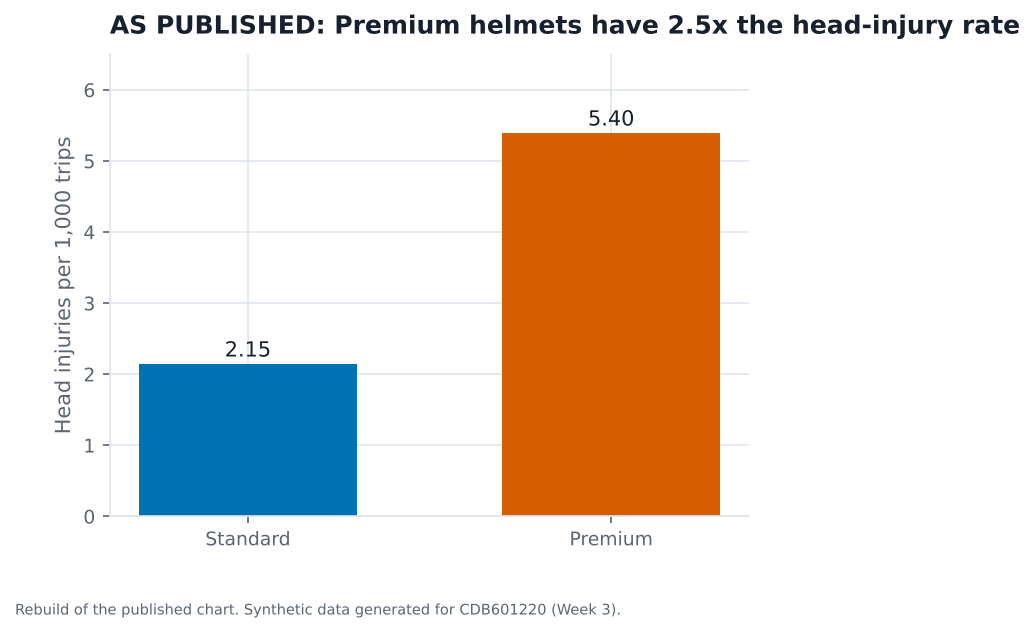

saved -> charts/partA_case01_rebuild.png


'/home/claude/week3/charts/partA_case01_rebuild.png'

In [3]:
helmet = pd.read_csv(DATA / "case01_helmet_rickshaw.csv")
pooled = helmet.groupby("helmet_grade")[["head_injuries", "trips"]].sum()
pooled["per_1000"] = 1000 * pooled.head_injuries / pooled.trips
print(pooled)

check(1, "Standard per 1,000", pooled.loc["Standard", "per_1000"], 2.15, 0.005)
check(1, "Premium per 1,000", pooled.loc["Premium", "per_1000"], 5.40, 0.005)

fig, ax = plt.subplots(figsize=(5.5, 4))
order = ["Standard", "Premium"]
ax.bar(order, pooled.loc[order, "per_1000"], color=[BLUE, ORANGE], width=0.6)
for i, g in enumerate(order):
    ax.text(i, pooled.loc[g, "per_1000"] + 0.1, f"{pooled.loc[g, 'per_1000']:.2f}", ha="center")
ax.set_ylim(0, 6.5)
ax.set_ylabel("Head injuries per 1,000 trips")
ax.set_title("AS PUBLISHED: Premium helmets have 2.5x the head-injury rate")
finish(fig, "partA_case01_rebuild", "Rebuild of the published chart. " + SRC)

**What this chart shows.** This is the chart the way the analyst drew it. Just looking at it, Premium helmets look 2.5 times worse, because their bar is way taller. But it mixes all three road types together, and the two helmet groups don't ride on the same roads.

In [4]:
# Decoy test: is it the riders? (experience and speed are columns the chart never used)
print(helmet.groupby("helmet_grade")[["months_experience", "avg_speed_kph"]].mean().round(1))
print()
print("speed inside each road type:")
print(helmet.groupby(["road_type", "helmet_grade"]).avg_speed_kph.mean().unstack().round(1))

              months_experience  avg_speed_kph
helmet_grade                                  
Premium                    31.4           67.0
Standard                   31.5           30.2

speed inside each road type:
helmet_grade      Premium  Standard
road_type                          
City arterial        39.6      38.0
Inner-city lanes     25.6      24.0
Motorway             72.2      71.0


In [5]:
# Mechanism: where do the trips happen?
share = pd.crosstab(helmet.road_type, helmet.helmet_grade, values=helmet.trips,
                    aggfunc="sum", normalize="columns")
print("share of each grade's trips by road type:")
print((100 * share).round(1))

strat = helmet.groupby(["road_type", "helmet_grade"])[["head_injuries", "trips"]].sum()
strat["per_1000"] = 1000 * strat.head_injuries / strat.trips
print()
print(strat.round(2))
rate = strat.per_1000.unstack()
print()
print("Premium is lower than Standard on every road:", bool((rate.Premium < rate.Standard).all()))
print("relative reduction:", (100 * (1 - rate.Premium / rate.Standard)).round(0).to_dict())

share of each grade's trips by road type:
helmet_grade      Premium  Standard
road_type                          
City arterial        12.5      33.3
Inner-city lanes      2.5      63.3
Motorway             85.0       3.3

                               head_injuries  trips  per_1000
road_type        helmet_grade                                
City arterial    Premium                  11   5000      2.20
                 Standard                 60  20000      3.00
Inner-city lanes Premium                   1   1000      1.00
                 Standard                 53  38000      1.39
Motorway         Premium                 204  34000      6.00
                 Standard                 16   2000      8.00

Premium is lower than Standard on every road: True
relative reduction: {'City arterial': 27.0, 'Inner-city lanes': 28.0, 'Motorway': 25.0}


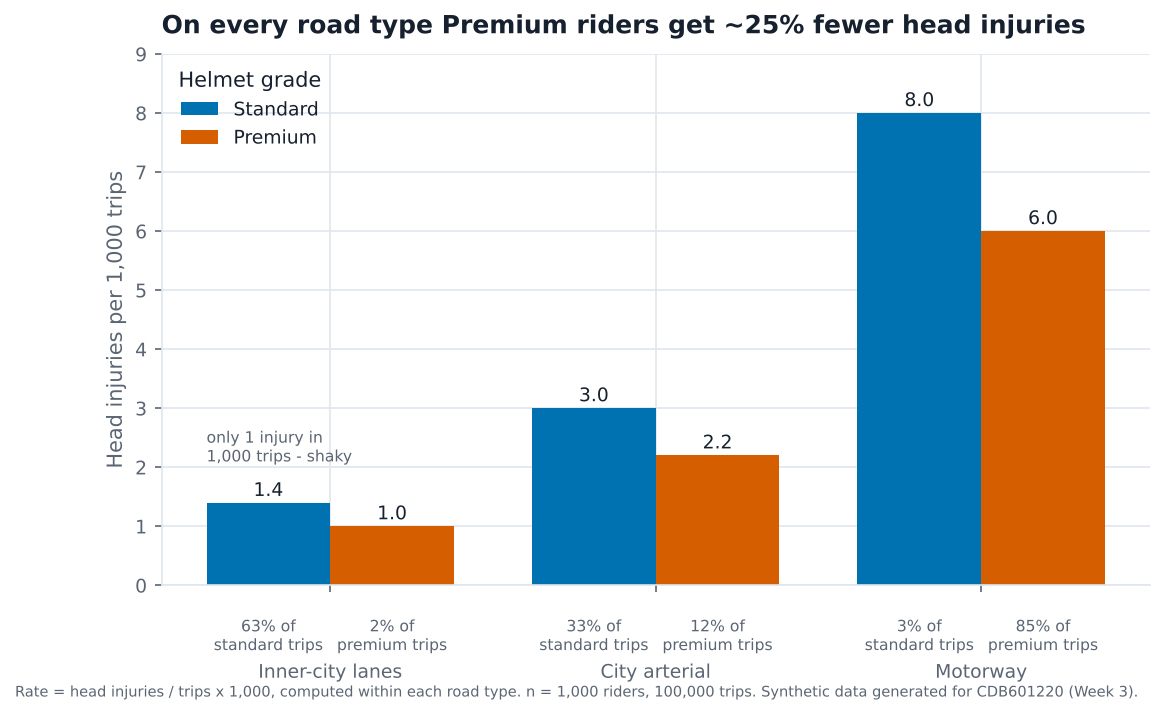

saved -> charts/partA_case01_redesign.png


'/home/claude/week3/charts/partA_case01_redesign.png'

In [6]:
roads = ["Inner-city lanes", "City arterial", "Motorway"]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
w = 0.38
for k, (g, col) in enumerate([("Standard", BLUE), ("Premium", ORANGE)]):
    xs = np.arange(len(roads)) + (k - 0.5) * w
    vals = [rate.loc[r, g] for r in roads]
    ax.bar(xs, vals, width=w, color=col, label=g)
    for x, r, v in zip(xs, roads, vals):
        ax.text(x, v + 0.12, f"{v:.1f}", ha="center", fontsize=9, color=INK)
        ax.text(x, -0.55, f"{100*share.loc[r, g]:.0f}% of\n{g.lower()} trips", ha="center",
                fontsize=7.5, color=INK_SOFT, va="top")
ax.set_xticks(range(len(roads)))
ax.set_xticklabels(roads)
ax.tick_params(axis="x", pad=34)
ax.set_ylim(0, 9)
ax.set_ylabel("Head injuries per 1,000 trips")
ax.legend(title="Helmet grade", loc="upper left")
ax.set_title("On every road type Premium riders get ~25% fewer head injuries")
ax.text(-0.38, 2.1, "only 1 injury in\n1,000 trips - shaky", fontsize=7.5, color=INK_SOFT)
finish(fig, "partA_case01_redesign",
       "Rate = head injuries / trips x 1,000, computed within each road type. n = 1,000 riders, 100,000 trips. " + SRC)

**What this chart shows.** Once I split the trips by road type, the story flips. Premium has fewer head injuries on every road, about 25% fewer. It only looked worse before because 85% of Premium trips are on motorways, which is the most dangerous road.

### Case 1 diagnosis

**The conclusion it invites.** The chart invites me to conclude that Premium helmets are more dangerous than Standard ones: 5.40 head injuries per 1,000 trips against 2.15.

**The decoy, and why it does not hold.** My first thought was risk compensation: riders who buy the expensive helmet feel safe and ride badly, or they are newer riders. The data rules that out. Average experience is the same in both groups (31.4 vs 31.5 months). Premium riders are faster on average (67 vs 30 km/h), but inside each road type the speeds are almost identical (motorway 72.2 vs 71.0, city arterial 39.6 vs 38.0, inner-city lanes 25.6 vs 24.0). The speed gap is just the road gap.

**The mechanism.** Simpson's paradox, with road type as the hidden variable. 85% of Premium trips are on motorways, but only 3.3% of Standard trips are. Motorways are by far the most dangerous road (6 to 8 injuries per 1,000 trips, against 1 to 1.4 in the lanes). When I compare the helmets on the same road, Premium is lower on every single one: motorway 6.0 vs 8.0, city arterial 2.2 vs 3.0, inner-city lanes 1.0 vs 1.4. That is roughly 25% fewer injuries with Premium. The headline reverses because the two groups ride on different roads, not because the helmet is worse.

**The redesign.** One panel per road type, both helmets side by side, with the share of trips written under each bar. The comparison is now like for like, and the reader can see why the pooled number was misleading. (Premium in the lanes is only 1 injury in 1,000 trips, so that bar is shaky and I say so on the chart.)

---
## Case 2 - "Canteen chai sales predict quiz failures"

> Scatter `cups_doodh_patti_sold` (x) against `quiz_failures` (y), one point per month. Fit a least-squares line and annotate Pearson r.

**Self-check:** r = 0.98.

self-check case 2: Pearson r = 0.982 (want 0.98)  ->  PASS


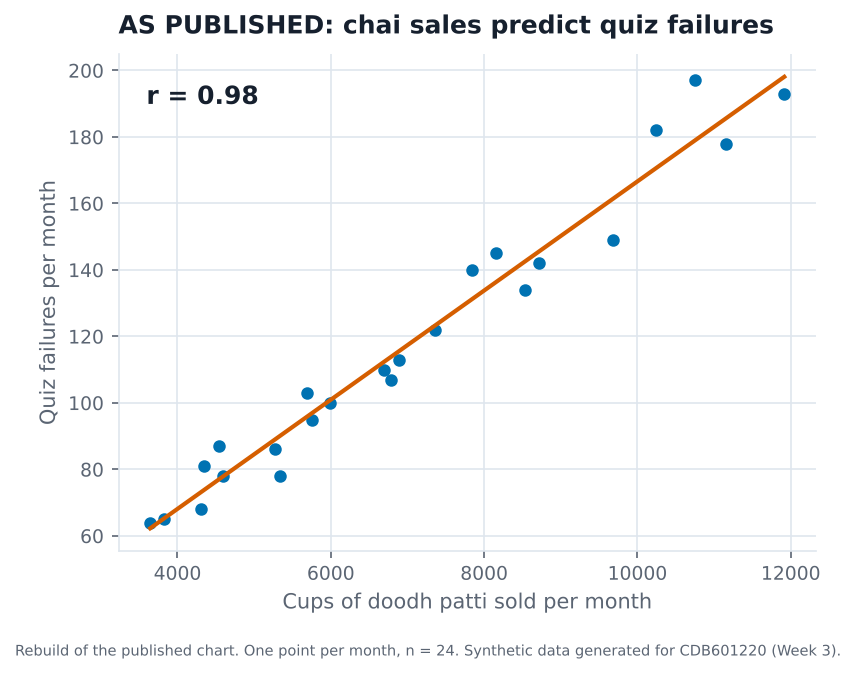

saved -> charts/partA_case02_rebuild.png


'/home/claude/week3/charts/partA_case02_rebuild.png'

In [7]:
chai = pd.read_csv(DATA / "case02_chai_quizzes.csv")
r = np.corrcoef(chai.cups_doodh_patti_sold, chai.quiz_failures)[0, 1]
check(2, "Pearson r", r, 0.98, 0.005)

fig, ax = plt.subplots(figsize=(6, 4.3))
ax.scatter(chai.cups_doodh_patti_sold, chai.quiz_failures, color=BLUE)
b = np.polyfit(chai.cups_doodh_patti_sold, chai.quiz_failures, 1)
xs = np.linspace(chai.cups_doodh_patti_sold.min(), chai.cups_doodh_patti_sold.max(), 50)
ax.plot(xs, np.polyval(b, xs), color=ORANGE)
ax.text(0.04, 0.9, f"r = {r:.2f}", transform=ax.transAxes, fontsize=12, fontweight="bold")
ax.set_xlabel("Cups of doodh patti sold per month")
ax.set_ylabel("Quiz failures per month")
ax.set_title("AS PUBLISHED: chai sales predict quiz failures")
finish(fig, "partA_case02_rebuild", "Rebuild of the published chart. One point per month, n = 24. " + SRC)

**What this chart shows.** Here the line fits almost perfectly (r = 0.98), so it looks like more chai means more failed quizzes. But both numbers are just counts, and over these two years the number of students tripled.

In [8]:
# Decoy test: exam months. If stress were the link, it should vanish inside each group.
for e, g in chai.groupby("is_exam_month"):
    print(f"is_exam_month={e}: n={len(g)}, r = {np.corrcoef(g.cups_doodh_patti_sold, g.quiz_failures)[0,1]:.3f}")

# Mechanism: head-count
print()
print(chai[["students_enrolled", "cups_doodh_patti_sold", "quiz_failures"]].corr().round(3))
print("enrolment grew", chai.students_enrolled.iloc[0], "->", chai.students_enrolled.iloc[-1],
      f"({chai.students_enrolled.iloc[-1]/chai.students_enrolled.iloc[0]:.1f}x)")

chai["cups_per_student"] = chai.cups_doodh_patti_sold / chai.students_enrolled
chai["fails_per_100"] = 100 * chai.quiz_failures / chai.students_enrolled
r_ps = np.corrcoef(chai.cups_per_student, chai.fails_per_100)[0, 1]
z, se = np.arctanh(r_ps), 1 / np.sqrt(len(chai) - 3)
lo, hi = np.tanh([z - 1.96 * se, z + 1.96 * se])
print(f"per-student r = {r_ps:.2f}, 95% CI {lo:.2f} to {hi:.2f}")

is_exam_month=0: n=16, r = 0.996
is_exam_month=1: n=8, r = 0.996

                       students_enrolled  cups_doodh_patti_sold  quiz_failures
students_enrolled                  1.000                  0.997          0.977
cups_doodh_patti_sold              0.997                  1.000          0.982
quiz_failures                      0.977                  0.982          1.000
enrolment grew 1765 -> 5406 (3.1x)
per-student r = 0.29, 95% CI -0.12 to 0.62


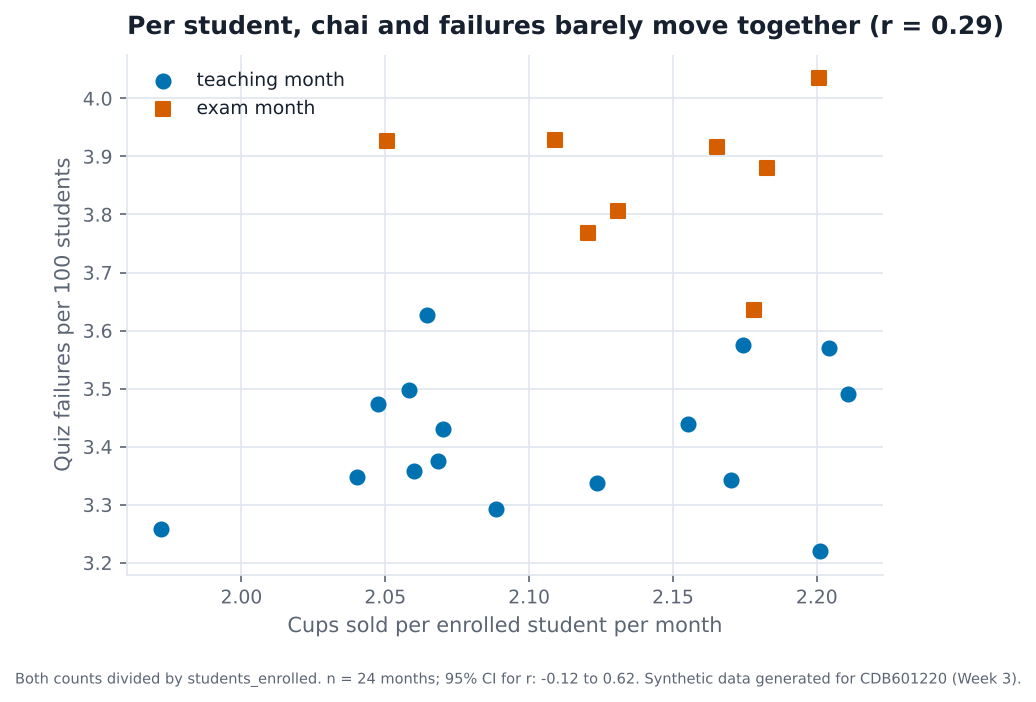

saved -> charts/partA_case02_redesign.png


'/home/claude/week3/charts/partA_case02_redesign.png'

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for e, (lab, col, mk) in {0: ("teaching month", BLUE, "o"), 1: ("exam month", ORANGE, "s")}.items():
    g = chai[chai.is_exam_month == e]
    ax.scatter(g.cups_per_student, g.fails_per_100, color=col, marker=mk, s=45, label=lab)
ax.set_xlabel("Cups sold per enrolled student per month")
ax.set_ylabel("Quiz failures per 100 students")
ax.legend(loc="upper left")
ax.set_title(f"Per student, chai and failures barely move together (r = {r_ps:.2f})")
finish(fig, "partA_case02_redesign",
       f"Both counts divided by students_enrolled. n = 24 months; 95% CI for r: {lo:.2f} to {hi:.2f}. " + SRC)

**What this chart shows.** When I divide both by how many students were enrolled, most of the link disappears (r = 0.29, and with 24 months that could easily be zero). The main thing that pushes failures up per student is exam months, which has nothing to do with chai.

### Case 2 diagnosis

**The conclusion it invites.** The chart says that months with more doodh patti sold are months with more quiz failures (r = 0.98), so chai seems to be bad for marks.

**The decoy, and why it does not hold.** I first thought exam months: stress makes students drink more chai and also fail more quizzes. But if that were the reason, the link should vanish inside each group. It does not: r = 0.996 in non-exam months and r = 0.996 in exam months. Exam months are not what is producing the line.

**The mechanism.** Both counts are driven by head-count. Enrolment grew 3.1x over the 24 months (1,765 to 5,406 students). Cups sold track enrolment at r = 0.997 and failures track it at r = 0.977. More students means more cups and more failures. When I divide both by students enrolled, the correlation falls from 0.98 to 0.29, and with only 24 months its 95% interval runs from below zero to about 0.6. Per student there is no clear link at all. The one thing that does move failures per student is the exam calendar: 3.86 failures per 100 students in exam months against 3.41 in teaching months, which makes sense, but has nothing to do with chai.

**The redesign.** A scatter of cups per student against failures per student, with exam months marked by a different shape. The honest title is that per student the two barely move together.

---
## Case 3 - "The Smog Action Plan cut Lahore's AQI by a third"

> Mean `aqi` per `date` across every row. Line, y-axis from zero. Vertical marker at day 61; horizontal mean lines for days 1-60 and 61-120.

**Self-check:** before 202, after 137 - a 32% fall.

self-check case 3: mean AQI days 1-60 = 202.095 (want 202)  ->  PASS
self-check case 3: mean AQI days 61-120 = 137.206 (want 137)  ->  PASS
self-check case 3: fall % = 32.108 (want 32)  ->  PASS


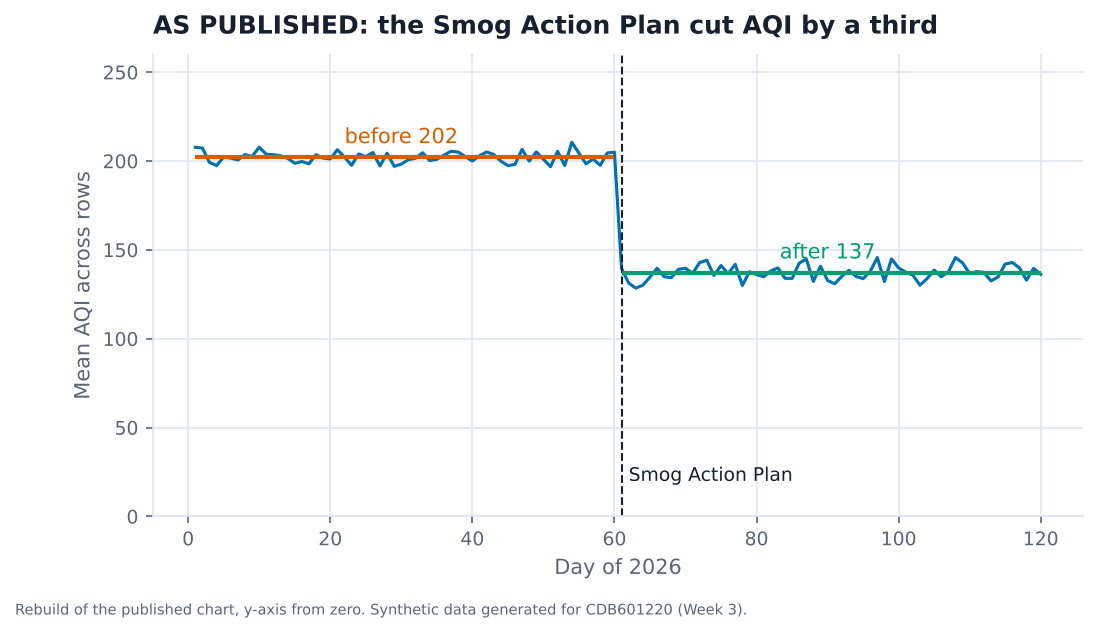

saved -> charts/partA_case03_rebuild.png


'/home/claude/week3/charts/partA_case03_rebuild.png'

In [10]:
aqi = pd.read_csv(DATA / "case03_aqi_monitors.csv", parse_dates=["date"])
aqi["day"] = (aqi.date - aqi.date.min()).dt.days + 1
daily = aqi.groupby("day").aqi.mean()          # this is what the analyst did: blanks silently skipped
before, after = daily[daily.index <= 60].mean(), daily[daily.index > 60].mean()
check(3, "mean AQI days 1-60", before, 202, 0.5)
check(3, "mean AQI days 61-120", after, 137, 0.5)
check(3, "fall %", 100 * (1 - after / before), 32, 0.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(daily.index, daily.values, color=BLUE, lw=1.5)
ax.axvline(61, color=INK, ls="--", lw=1)
ax.hlines(before, 1, 60, color=ORANGE, lw=2)
ax.hlines(after, 61, 120, color=GREEN, lw=2)
ax.text(30, before + 8, f"before {before:.0f}", ha="center", color=ORANGE)
ax.text(90, after + 8, f"after {after:.0f}", ha="center", color=GREEN)
ax.text(62, 20, "Smog Action Plan", fontsize=9)
ax.set_ylim(0, 260)
ax.set_xlabel("Day of 2026")
ax.set_ylabel("Mean AQI across rows")
ax.set_title("AS PUBLISHED: the Smog Action Plan cut AQI by a third")
finish(fig, "partA_case03_rebuild", "Rebuild of the published chart, y-axis from zero. " + SRC)

**What this chart shows.** The average AQI falls sharply on day 61, from 202 to 137, so the plan looks like a big success. The axis starts at zero, so this isn't an axis trick. Something else changed on that day.

In [11]:
aqi["period"] = np.where(aqi.day <= 60, "before", "after")
print("rows with blank aqi:", aqi.aqi.isna().sum(), "| status offline:", (aqi.station_status == "offline").sum())
reporting = aqi.groupby("day").aqi.count()
print("stations reporting per day, before vs after:", reporting[reporting.index <= 60].unique(),
      reporting[reporting.index > 60].unique())

print()
print("share of station-days reporting, by zone:")
print(aqi.assign(rep=aqi.aqi.notna()).groupby(["zone", "period"]).rep.mean().unstack()[["before", "after"]])

dropped = aqi[(aqi.period == "after")].groupby("station_id").aqi.count()
dropped = dropped[dropped == 0].index
print()
print("stations that went silent on day 61:", list(dropped))
print(aqi[aqi.station_id.isin(dropped)].drop_duplicates("station_id").zone.value_counts())

stayed = aqi[~aqi.station_id.isin(dropped)]
same = stayed.groupby("period").aqi.mean()
print()
print(f"same 13 stations: before {same['before']:.1f}, after {same['after']:.1f}  "
      f"({100*(same['after']/same['before']-1):+.1f}%)")
print("before-period mean of the 9 silent stations:", round(aqi[aqi.station_id.isin(dropped) & (aqi.period=='before')].aqi.mean(), 1))

rows with blank aqi: 540 | status offline: 540
stations reporting per day, before vs after: [22] [13]

share of station-days reporting, by zone:
period       before  after
zone                      
Arterial        1.0    0.5
Industrial      1.0    0.0
Peri-urban      1.0    1.0
Residential     1.0    1.0

stations that went silent on day 61: ['LHR-01', 'LHR-02', 'LHR-03', 'LHR-04', 'LHR-05', 'LHR-06', 'LHR-07', 'LHR-08', 'LHR-09']
zone
Industrial    6
Arterial      3
Name: count, dtype: int64

same 13 stations: before 137.1, after 137.2  (+0.1%)
before-period mean of the 9 silent stations: 296.0


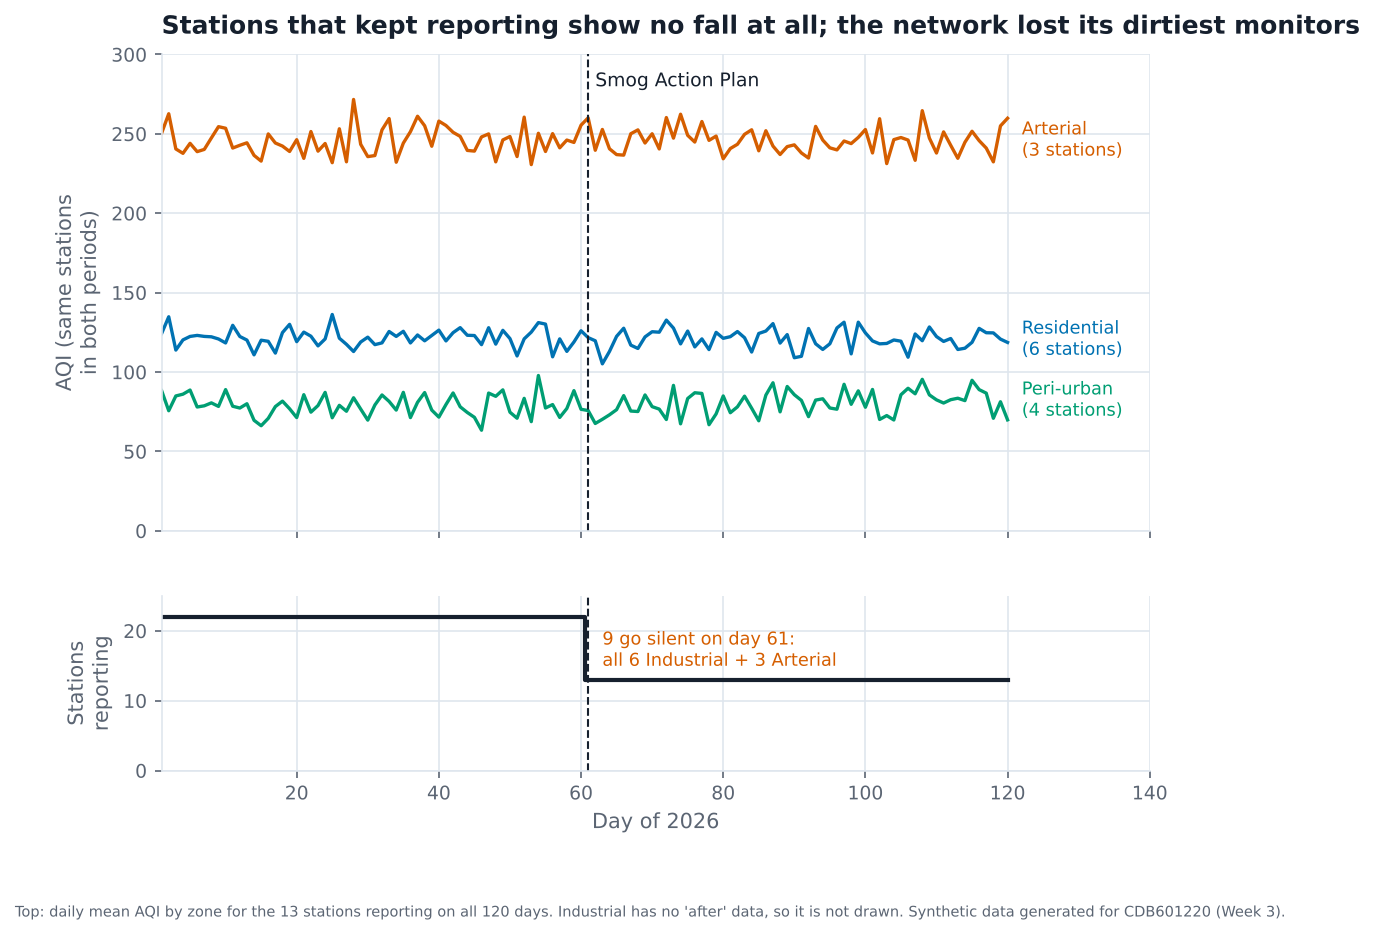

saved -> charts/partA_case03_redesign.png


'/home/claude/week3/charts/partA_case03_redesign.png'

In [12]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8.5, 6.2), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1.1]})
zone_style = {"Arterial": (ORANGE, "-"), "Residential": (BLUE, "-"), "Peri-urban": (GREEN, "-")}
for z, (col, ls) in zone_style.items():
    s = stayed[stayed.zone == z].groupby("day").aqi.mean()
    ax.plot(s.index, s.values, color=col, lw=1.6, ls=ls)
    ax.text(122, s.iloc[-10:].mean(), f"{z}\n({stayed[stayed.zone==z].station_id.nunique()} stations)",
            color=col, va="center", fontsize=8.5)
ax.axvline(61, color=INK, ls="--", lw=1)
ax.set_ylim(0, 300)
ax.set_ylabel("AQI (same stations\nin both periods)")
ax.set_title("Stations that kept reporting show no fall at all; the network lost its dirtiest monitors")
ax.text(62, 280, "Smog Action Plan", fontsize=9)
ax2.step(reporting.index, reporting.values, where="mid", color=INK)
ax2.axvline(61, color=INK, ls="--", lw=1)
ax2.set_ylim(0, 25)
ax2.set_ylabel("Stations\nreporting")
ax2.set_xlabel("Day of 2026")
ax2.text(63, 15, "9 go silent on day 61:\nall 6 Industrial + 3 Arterial", fontsize=8.5, color=ORANGE)
ax.set_xlim(1, 140)
finish(fig, "partA_case03_redesign",
       "Top: daily mean AQI by zone for the 13 stations reporting on all 120 days. Industrial has no 'after' data, so it is not drawn. " + SRC)

**What this chart shows.** The bottom panel shows the real reason: on day 61, 9 of the 22 stations stopped reporting, and those were the most polluted ones (all the Industrial stations). The stations that kept reporting stay flat, so air quality didn't actually improve. The average just lost its dirtiest monitors.

### Case 3 diagnosis

**The conclusion it invites.** The line drops on day 61 from a mean of 202 to 137, so the chart says the Smog Action Plan cut air pollution by 32%.

**The decoy, and why it does not hold.** The usual objection is a truncated axis. That is ruled out because the recipe made me draw the y-axis from zero, so the fall is not an axis trick. The second objection is the season (winter smog clears by spring). I tested that too: stations that reported in both periods show no fall at all, so there is no seasonal drop in this data either.

**The mechanism.** The stations that went offline are not random. From day 61, 9 of the 22 stations stopped reporting: all 6 Industrial stations and 3 of the 6 Arterial ones. Before the plan those 9 averaged an AQI of 296, against 137 for the stations that stayed. The daily mean is a mean over whichever stations were reporting, and pandas skips the blanks silently. So the dirtiest monitors dropped out of the average and the average fell. For the 13 stations that reported the whole time, AQI went from 137.1 to 137.2, which is flat (+0.1%). The plan did nothing visible; the network shrank.

**The redesign.** Two panels. The top one plots AQI per zone using only stations that reported in both periods. The bottom one plots how many stations were reporting each day. The 22 to 13 drop on day 61 is now right under the reader's eyes.

---
## Case 4 - "Four departments behave identically, so fund them equally"

> Not a chart. A table: n, mean study hours, mean score, SD of each, Pearson r and the regression slope - one column per `department`.

**Self-check:** every department reports mean 18.00 / 14.50 and r = 0.816.

In [13]:
def stats_table(df, group, x, y):
    out = {}
    for k, g in df.groupby(group):
        slope, icpt = np.polyfit(g[x], g[y], 1)
        out[k] = {"n": len(g), f"mean {x}": g[x].mean(), f"mean {y}": g[y].mean(),
                  f"SD {x}": g[x].std(ddof=0), f"SD {y}": g[y].std(ddof=0),
                  "Pearson r": np.corrcoef(g[x], g[y])[0, 1], "slope": slope, "intercept": icpt}
    return pd.DataFrame(out)


dept = pd.read_csv(DATA / "case04_quartet_depts.csv")
X4, Y4 = "study_hours_per_week", "final_score_out_of_20"
t4 = stats_table(dept, "department", X4, Y4)
print(t4.round(3))
for d_ in t4.columns:
    check(4, f"{d_} mean hours", t4.loc[f"mean {X4}", d_], 18.00, 0.005)
    check(4, f"{d_} mean score", t4.loc[f"mean {Y4}", d_], 14.50, 0.005)
    check(4, f"{d_} r", t4.loc["Pearson r", d_], 0.816, 0.0015)

                            Architecture  Business Administration  Computer Science  Electrical Engineering
n                                 11.000                   11.000            11.000                  11.000
mean study_hours_per_week         18.000                   18.000            18.000                  18.000
mean final_score_out_of_20        14.501                   14.501            14.501                  14.500
SD study_hours_per_week            6.325                    6.325             6.325                   6.325
SD final_score_out_of_20           1.936                    1.937             1.937                   1.936
Pearson r                          0.817                    0.816             0.816                   0.816
slope                              0.250                    0.250             0.250                   0.250
intercept                         10.002                   10.001            10.000                  10.002
self-check case 4: Architect

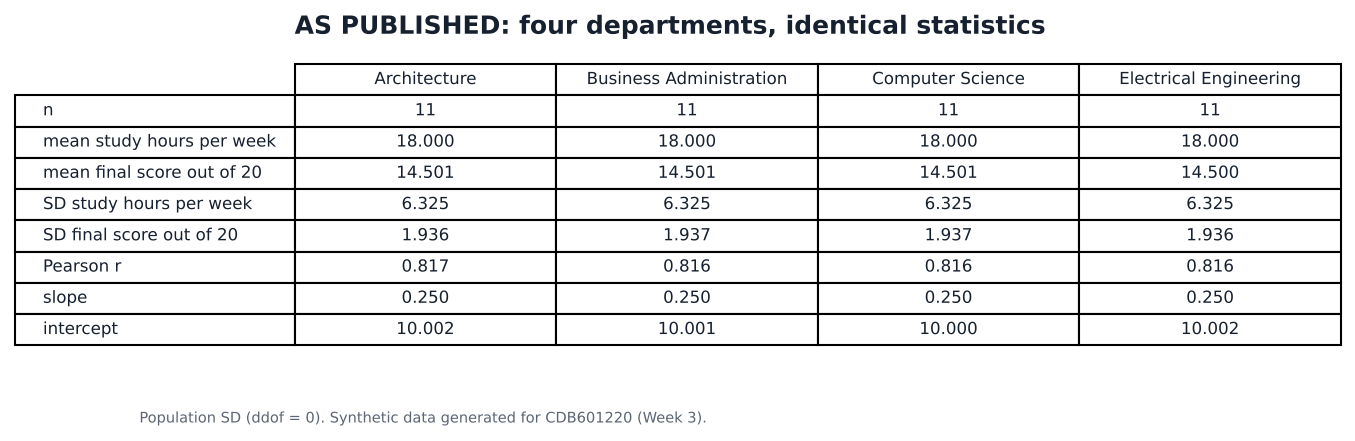

saved -> charts/partA_case04_rebuild.png


'/home/claude/week3/charts/partA_case04_rebuild.png'

In [14]:
# Rebuild = the table as a figure, so it can go in the PDF
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axis("off")
cell = pd.DataFrame([[f"{int(v)}" if i == "n" else f"{v:.3f}" for v in t4.loc[i]] for i in t4.index],
                    index=t4.index, columns=t4.columns)
tb = ax.table(cellText=cell.values, rowLabels=[i.replace("_", " ") for i in cell.index],
              colLabels=cell.columns, loc="center", cellLoc="center")
tb.auto_set_font_size(False); tb.set_fontsize(8); tb.scale(1, 1.25)
ax.set_title("AS PUBLISHED: four departments, identical statistics", loc="left")
finish(fig, "partA_case04_rebuild", "Population SD (ddof = 0). " + SRC)

**What this chart shows.** The table makes the four departments look exactly the same: same means, same SDs, same r and the same slope. Going by these numbers you'd treat all four the same way.

In [15]:
# Mechanism: look at each department's points
for k, g in dept.groupby("department"):
    print(f"{k:24s} cohort {g.cohort_group.iloc[0]:>3}  distinct hour values: {g[X4].nunique():2d}  "
          f"max residual from shared line: {np.abs(g[Y4] - (0.25*g[X4] + 10)).max():.2f}")
arch = dept[dept.department == "Architecture"]
print()
print("Architecture hours:", sorted(arch[X4].tolist()))
print("Architecture without the 38-hour student, distinct x values:",
      arch[arch[X4] != 38][X4].nunique(), "(so r cannot be computed)")

Architecture             cohort  IV  distinct hour values:  2  max residual from shared line: 1.84
Business Administration  cohort  II  distinct hour values: 11  max residual from shared line: 1.90
Computer Science         cohort   I  distinct hour values: 11  max residual from shared line: 1.92
Electrical Engineering   cohort III  distinct hour values: 11  max residual from shared line: 3.24

Architecture hours: [16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 38.0]
Architecture without the 38-hour student, distinct x values: 1 (so r cannot be computed)


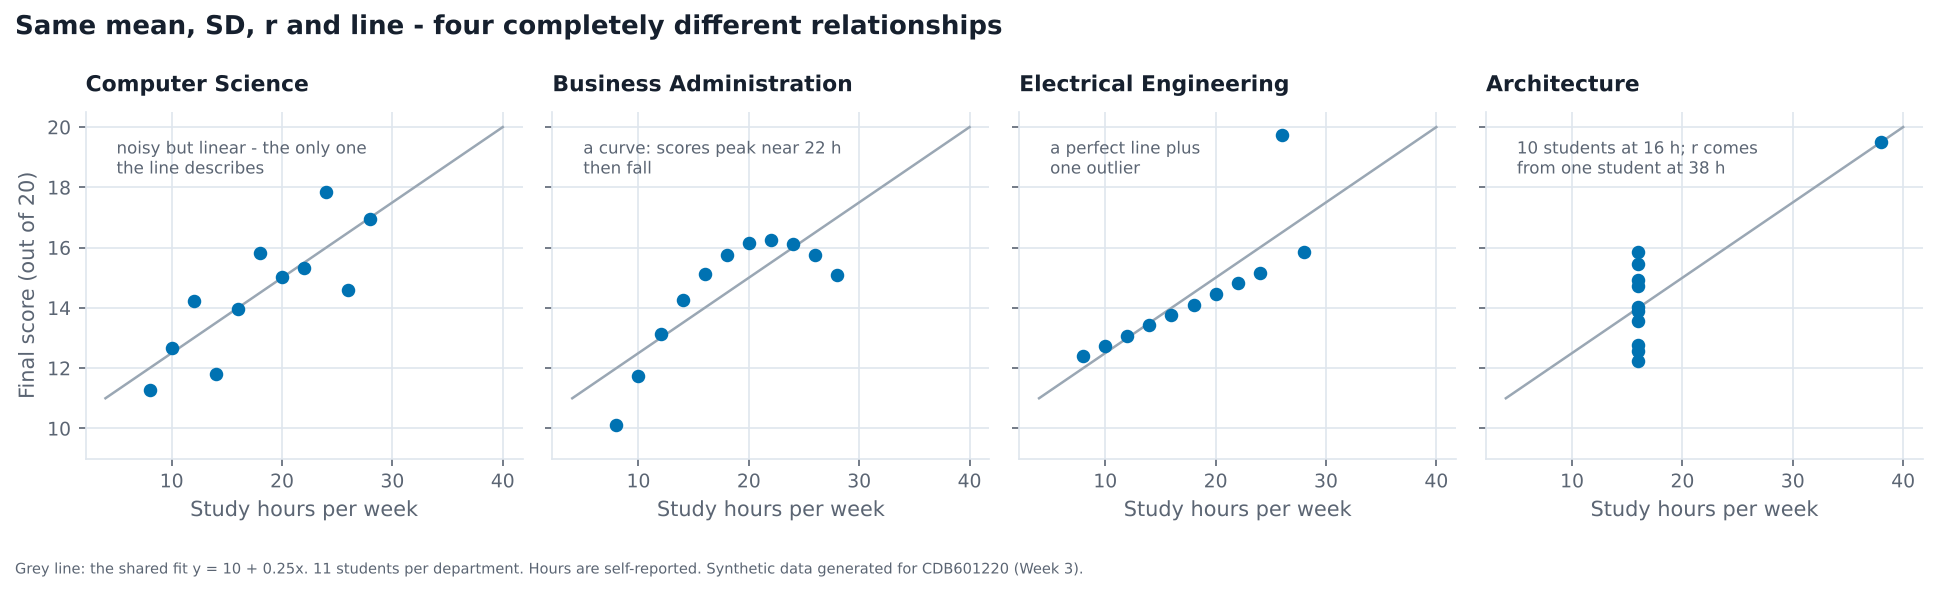

saved -> charts/partA_case04_redesign.png


'/home/claude/week3/charts/partA_case04_redesign.png'

In [16]:
desc = {"Computer Science": "noisy but linear - the only one\nthe line describes",
        "Business Administration": "a curve: scores peak near 22 h\nthen fall",
        "Electrical Engineering": "a perfect line plus\none outlier",
        "Architecture": "10 students at 16 h; r comes\nfrom one student at 38 h"}
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharex=True, sharey=True)
xs = np.linspace(4, 40, 10)
for ax, (k, txt) in zip(axes, desc.items()):
    g = dept[dept.department == k]
    ax.plot(xs, 0.25 * xs + 10, color=GREY, lw=1.2, zorder=1)
    ax.scatter(g[X4], g[Y4], color=BLUE, s=30, zorder=2)
    ax.set_title(k, fontsize=10.5)
    ax.text(5, 19.6, txt, fontsize=8, color=INK_SOFT, va="top")
    ax.set_xlabel("Study hours per week")
axes[0].set_ylabel("Final score (out of 20)")
axes[0].set_ylim(9, 20.5)
fig.suptitle("Same mean, SD, r and line - four completely different relationships", x=0.01, ha="left",
             fontweight="bold", fontsize=12.5)
fig.tight_layout()
finish(fig, "partA_case04_redesign",
       "Grey line: the shared fit y = 10 + 0.25x. 11 students per department. Hours are self-reported. " + SRC)

**What this chart shows.** When I plot the points, the four departments look nothing alike. Only Computer Science really follows a straight line. Business is a curve, Electrical has one outlier, and in Architecture the whole correlation comes from one student. The summary numbers hid all of that.

### Case 4 diagnosis

**The conclusion it invites.** The table says the four departments are the same: every one has mean 18.00 hours, mean score 14.50, r = 0.816 and slope 0.25, so one policy should fit all of them.

**The decoy, and why it does not hold.** I first thought n = 11 per department is too small to say anything. But small samples do not make four groups report identical statistics to two decimals, and once plotted the differences are obvious even with 11 points. The sample size is not the problem; the summary is.

**The mechanism.** This is Anscombe's quartet. The same numbers come from four completely different shapes. Computer Science is the only department where a straight line is a fair summary. Business Administration is a smooth curve: scores rise to about 22 hours a week and then fall, so more study past that point is linked with lower marks. Electrical Engineering is a perfect line except for one student (26 hours, 19.7). In Architecture, 10 of the 11 students report exactly 16 hours; the whole slope and the whole r = 0.816 come from one student who reported 38 hours. Take him out and the correlation cannot even be computed, because x no longer varies.

**The redesign.** Four small scatter plots on shared axes, with the common regression line in grey. Each department gets its own one-line description. Funding them the same way because their summaries match would be a decision based on four numbers that hide the data.

---
## Case 5 - "Five cohorts, one set of statistics"

> Also not a chart. The same table, one column per `shape_name`.

**Self-check:** every cohort reports 48.00 / 63.00, SD 12.00 / 15.00, r = 0.420.

                           ring     star  straight line  the letter X  two clusters
n                       180.000  180.000        180.000       180.000       180.000
mean hours_on_platform   48.000   48.000         48.000        48.000        48.000
mean assessment_score    63.000   63.000         63.000        63.000        63.000
SD hours_on_platform     12.000   12.000         12.000        12.000        12.000
SD assessment_score      15.000   15.000         15.000        15.000        15.000
Pearson r                 0.420    0.420          0.420         0.420         0.420
slope                     0.525    0.525          0.525         0.525         0.525
intercept                37.800   37.800         37.800        37.800        37.800
self-check case 5: ring mean x = 48.000 (want 48.0)  ->  PASS
self-check case 5: ring mean y = 63.000 (want 63.0)  ->  PASS
self-check case 5: ring SD x = 12.000 (want 12.0)  ->  PASS
self-check case 5: ring SD y = 15.000 (want 15.0)  ->  PASS


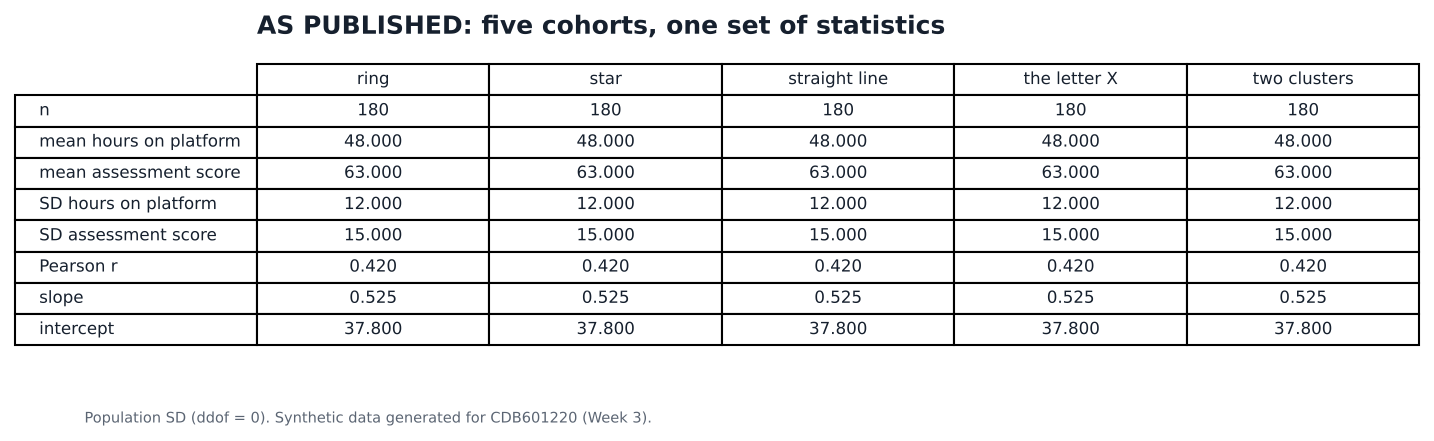

saved -> charts/partA_case05_rebuild.png


'/home/claude/week3/charts/partA_case05_rebuild.png'

In [17]:
shapes = pd.read_csv(DATA / "case05_same_stats_shapes.csv")
X5, Y5 = "hours_on_platform", "assessment_score"
t5 = stats_table(shapes, "shape_name", X5, Y5)
print(t5.round(3))
for s_ in t5.columns:
    check(5, f"{s_} mean x", t5.loc[f"mean {X5}", s_], 48.00, 0.005)
    check(5, f"{s_} mean y", t5.loc[f"mean {Y5}", s_], 63.00, 0.005)
    check(5, f"{s_} SD x", t5.loc[f"SD {X5}", s_], 12.00, 0.005)
    check(5, f"{s_} SD y", t5.loc[f"SD {Y5}", s_], 15.00, 0.005)
    check(5, f"{s_} r", t5.loc["Pearson r", s_], 0.420, 0.0005)

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.axis("off")
cell = pd.DataFrame([[f"{int(v)}" if i == "n" else f"{v:.3f}" for v in t5.loc[i]] for i in t5.index],
                    index=t5.index, columns=t5.columns)
tb = ax.table(cellText=cell.values, rowLabels=[i.replace("_", " ") for i in cell.index],
              colLabels=cell.columns, loc="center", cellLoc="center")
tb.auto_set_font_size(False); tb.set_fontsize(8); tb.scale(1, 1.25)
ax.set_title("AS PUBLISHED: five cohorts, one set of statistics", loc="left")
finish(fig, "partA_case05_rebuild", "Population SD (ddof = 0). " + SRC)

**What this chart shows.** Five cohorts with the same mean, the same SD and the same correlation. The numbers were forced to match, so they tell you nothing about what the data actually looks like.

In [18]:
# Mechanism: the 'two clusters' cohort. Split it at the gap and look inside each cluster.
tc = shapes[shapes.shape_name == "two clusters"].copy()
cut = tc[X5].median()
# use the biggest gap in x to split, not an arbitrary value
xs_sorted = np.sort(tc[X5].values)
gap_at = xs_sorted[np.argmax(np.diff(xs_sorted))]
tc["cluster"] = np.where(tc[X5] <= gap_at, "low", "high")
for c, g in tc.groupby("cluster"):
    print(f"{c:5s} cluster: n={len(g)}, r = {np.corrcoef(g[X5], g[Y5])[0,1]:+.2f}")
print("whole cohort r =", round(np.corrcoef(tc[X5], tc[Y5])[0, 1], 3))

# match_stats really can give ANY shape these numbers: a circle, forced
theta = np.linspace(0, 2 * np.pi, 180)
fx, fy = vizlib.match_stats(np.cos(theta), np.sin(theta) + 0.3 * np.cos(theta), 48, 63, 12, 15, 0.42)
print("a forced circle:", {k: round(v, 3) for k, v in vizlib.describe(fx, fy).items()})

high  cluster: n=90, r = -0.45
low   cluster: n=90, r = -0.57
whole cohort r = 0.42
a forced circle: {'n': 180, 'mean_x': 48.0, 'mean_y': 63.0, 'sd_x': 12.0, 'sd_y': 15.0, 'r': 0.42}


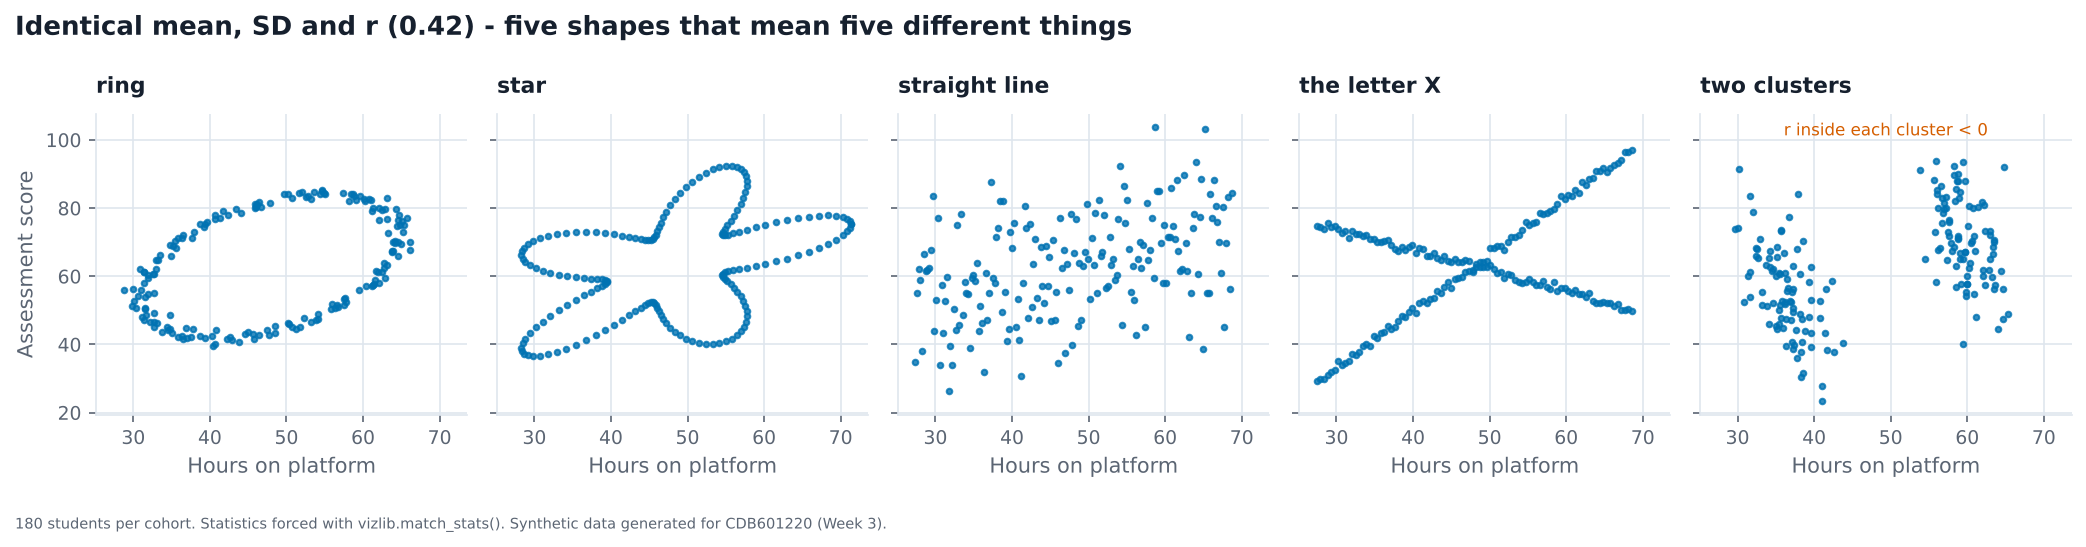

saved -> charts/partA_case05_redesign.png


'/home/claude/week3/charts/partA_case05_redesign.png'

In [19]:
names = list(t5.columns)
fig, axes = plt.subplots(1, 5, figsize=(14, 3.3), sharex=True, sharey=True)
for ax, nm in zip(axes, names):
    g = shapes[shapes.shape_name == nm]
    ax.scatter(g[X5], g[Y5], s=7, color=BLUE, alpha=0.8)
    ax.set_title(nm, fontsize=10.5)
    ax.set_xlabel("Hours on platform")
axes[0].set_ylabel("Assessment score")
axes[names.index("two clusters")].text(0.5, 0.97, "r inside each cluster < 0", ha="center", va="top", transform=axes[names.index("two clusters")].transAxes,
                                       fontsize=8, color=ORANGE)
fig.suptitle("Identical mean, SD and r (0.42) - five shapes that mean five different things", x=0.01, ha="left",
             fontweight="bold", fontsize=12.5)
fig.tight_layout()
finish(fig, "partA_case05_redesign", "180 students per cohort. Statistics forced with vizlib.match_stats(). " + SRC)

**What this chart shows.** Plotted, the five cohorts are a ring, a star, a line, an X and two clusters, which are completely different patterns. In the two-cluster group the correlation inside each cluster is actually negative. The positive r only comes from the gap between the two groups.

### Case 5 diagnosis

**The conclusion it invites.** The table says the five cohorts are interchangeable: mean 48.00 hours, mean score 63.00, SD 12.00 and 15.00, r = 0.420 in all five.

**The decoy, and why it does not hold.** With 180 students in each cohort it is tempting to say the numbers are reliable, so the cohorts really are alike. Large n does make these statistics precise, but precise statistics of the wrong summary are still the wrong summary.

**The mechanism.** The statistics were forced. vizlib.match_stats() standardises x, removes the part of y explained by x, and rebuilds y with exactly the target r. It keeps the shape, so any shape can be given any mean, SD and r. The clearest proof is the 'two clusters' cohort: inside each cluster the correlation is negative (r = -0.57 and -0.45). The whole +0.42 comes from the gap between the two clusters, not from more hours going with better scores. The 'ring', 'star' and 'letter X' cohorts have no linear trend a reader would recognise at all, and 'the letter X' is two opposite trends added together. Forcing the statistics also has side effects: in the 'straight line' cohort some scores reach 103.7, which is impossible if the assessment is out of 100.

**The redesign.** Five small scatter plots on the same axes. The shapes are the result; the table was never enough to describe them.

---
## Case 6 - "Creatinine tracks HbA1c - a finding"

> Correlation matrix of every numeric column except `age_band`, `study_site`, `hr_device_model`. Annotated heatmap exactly as the analyst did: `cmap="Reds"`, no `vmin`/`vmax`, both triangles.

**Self-check:** creatinine-hba1c = 0.77, systolic-map_mmhg = 0.96, matrix is 20 x 20.

self-check case 6: creatinine-hba1c = 0.765 (want 0.77)  ->  PASS
self-check case 6: systolic-map_mmhg = 0.958 (want 0.96)  ->  PASS
self-check case 6: matrix size = 400.000 (want 400)  ->  PASS


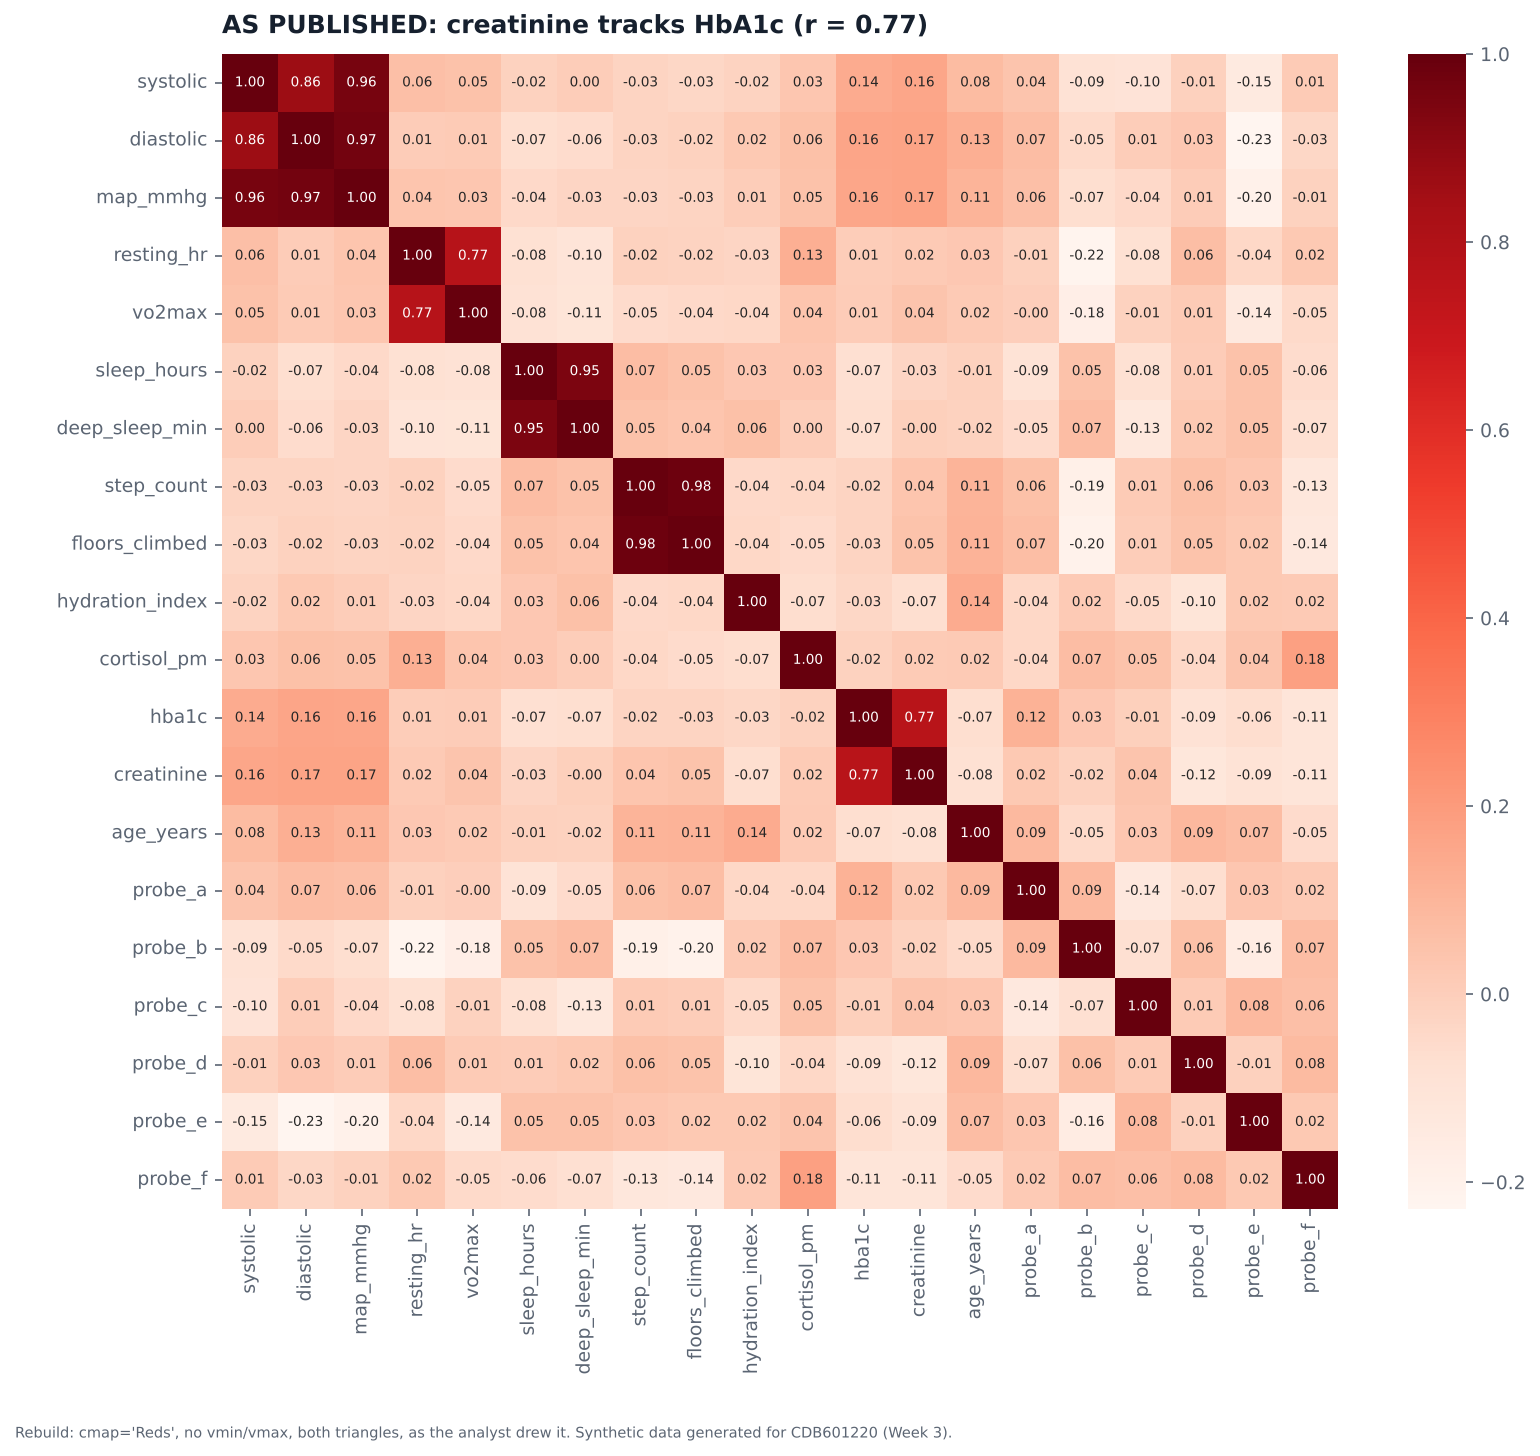

saved -> charts/partA_case06_rebuild.png


'/home/claude/week3/charts/partA_case06_rebuild.png'

In [20]:
sensor = pd.read_csv(DATA / "case06_sensor_matrix.csv")
num6 = sensor.drop(columns=["age_band", "study_site", "hr_device_model"])
corr6 = num6.corr()
check(6, "creatinine-hba1c", corr6.loc["creatinine", "hba1c"], 0.77, 0.005)
check(6, "systolic-map_mmhg", corr6.loc["systolic", "map_mmhg"], 0.96, 0.005)
check(6, "matrix size", corr6.shape[0] * corr6.shape[1], 400, 0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr6, cmap="Reds", annot=True, fmt=".2f", annot_kws={"size": 6.5}, ax=ax)
ax.set_title("AS PUBLISHED: creatinine tracks HbA1c (r = 0.77)")
finish(fig, "partA_case06_rebuild", "Rebuild: cmap='Reds', no vmin/vmax, both triangles, as the analyst drew it. " + SRC)

**What this chart shows.** This is the analyst's heatmap. Everything is red, so you can't tell a positive correlation from a negative one, and every number shows up twice. The creatinine–HbA1c value of 0.77 looks like a real finding.

In [21]:
# 1) the creatinine / HbA1c 'finding'
print(sensor[["creatinine", "hba1c"]].describe().round(2))
out = sensor[(sensor.creatinine > 300) | (sensor.hba1c > 12)]
print()
print("extreme rows:")
print(out[["creatinine", "hba1c", "study_site", "hr_device_model"]])
rest = sensor.drop(out.index)
print(f"r with the row: {corr6.loc['creatinine','hba1c']:.3f} | without it: "
      f"{np.corrcoef(rest.creatinine, rest.hba1c)[0,1]:.3f} | Spearman (all rows): "
      f"{stats.spearmanr(sensor.creatinine, sensor.hba1c)[0]:.3f}")

# decoy: is it the study site?
print()
for s_, g in sensor.groupby("study_site"):
    g2 = g.drop(out.index, errors="ignore")
    print(f"{s_}: r = {np.corrcoef(g.creatinine, g.hba1c)[0,1]:+.2f}  (without the extreme row {np.corrcoef(g2.creatinine, g2.hba1c)[0,1]:+.2f})")

       creatinine   hba1c
count      180.00  180.00
mean        87.36    5.62
std         73.02    0.98
min         54.20    4.20
25%         76.05    5.09
50%         81.55    5.54
75%         90.52    6.00
max       1050.00   15.80

extreme rows:
   creatinine  hba1c study_site hr_device_model
0      1050.0   15.8     Site C          DX-300
r with the row: 0.765 | without it: -0.004 | Spearman (all rows): 0.032

Site A: r = -0.05  (without the extreme row -0.05)
Site B: r = +0.34  (without the extreme row +0.34)
Site C: r = +0.92  (without the extreme row -0.11)
Site D: r = -0.11  (without the extreme row -0.11)


In [22]:
# 2) the other traps in the same matrix
print("map_mmhg is computed:", np.allclose(sensor.map_mmhg, (sensor.systolic + 2*sensor.diastolic)/3, atol=0.06))
print()
print("one device per site:")
print(pd.crosstab(sensor.study_site, sensor.hr_device_model))
print()
print(sensor.groupby("hr_device_model")[["resting_hr", "vo2max"]].mean().round(1))
print(f"\nresting_hr vs vo2max, pooled r = {corr6.loc['resting_hr','vo2max']:+.2f}")
for dv, g in sensor.groupby("hr_device_model"):
    print(f"  inside {dv}: r = {np.corrcoef(g.resting_hr, g.vo2max)[0,1]:+.2f}")

# 3) multiple comparisons: 190 pairs
iu = np.triu_indices(20, 1)
pvals = np.array([stats.pearsonr(num6.iloc[:, i], num6.iloc[:, j])[1] for i, j in zip(*iu)])
print(f"\npairs: {len(pvals)} | p < 0.05: {(pvals < 0.05).sum()} | expected by chance: {0.05*len(pvals):.1f} "
      f"| survive Bonferroni (p < {0.05/190:.5f}): {(pvals < 0.05/190).sum()}")
probe_hits = [(num6.columns[i], num6.columns[j], round(corr6.iloc[i, j], 2))
              for (i, j), p in zip(zip(*iu), pvals) if p < 0.05 and ("probe" in num6.columns[i] or "probe" in num6.columns[j])]
print("'significant' pairs involving uncalibrated probes:", len(probe_hits))
print(probe_hits[:5])

map_mmhg is computed: False

one device per site:
hr_device_model  DX-100  DX-200  DX-300  DX-400
study_site                                     
Site A               45       0       0       0
Site B                0      40       0       0
Site C                0       0      46       0
Site D                0       0       0      49

                 resting_hr  vo2max
hr_device_model                    
DX-100                 61.6    34.2
DX-200                 66.1    40.0
DX-300                 71.6    46.5
DX-400                 76.5    52.7

resting_hr vs vo2max, pooled r = +0.77
  inside DX-100: r = -0.41
  inside DX-200: r = -0.40
  inside DX-300: r = -0.50
  inside DX-400: r = -0.63

pairs: 190 | p < 0.05: 20 | expected by chance: 9.5 | survive Bonferroni (p < 0.00026): 7
'significant' pairs involving uncalibrated probes: 8
[('diastolic', 'probe_e', np.float64(-0.23)), ('map_mmhg', 'probe_e', np.float64(-0.2)), ('resting_hr', 'probe_b', np.float64(-0.22)), ('vo2max', 'probe_

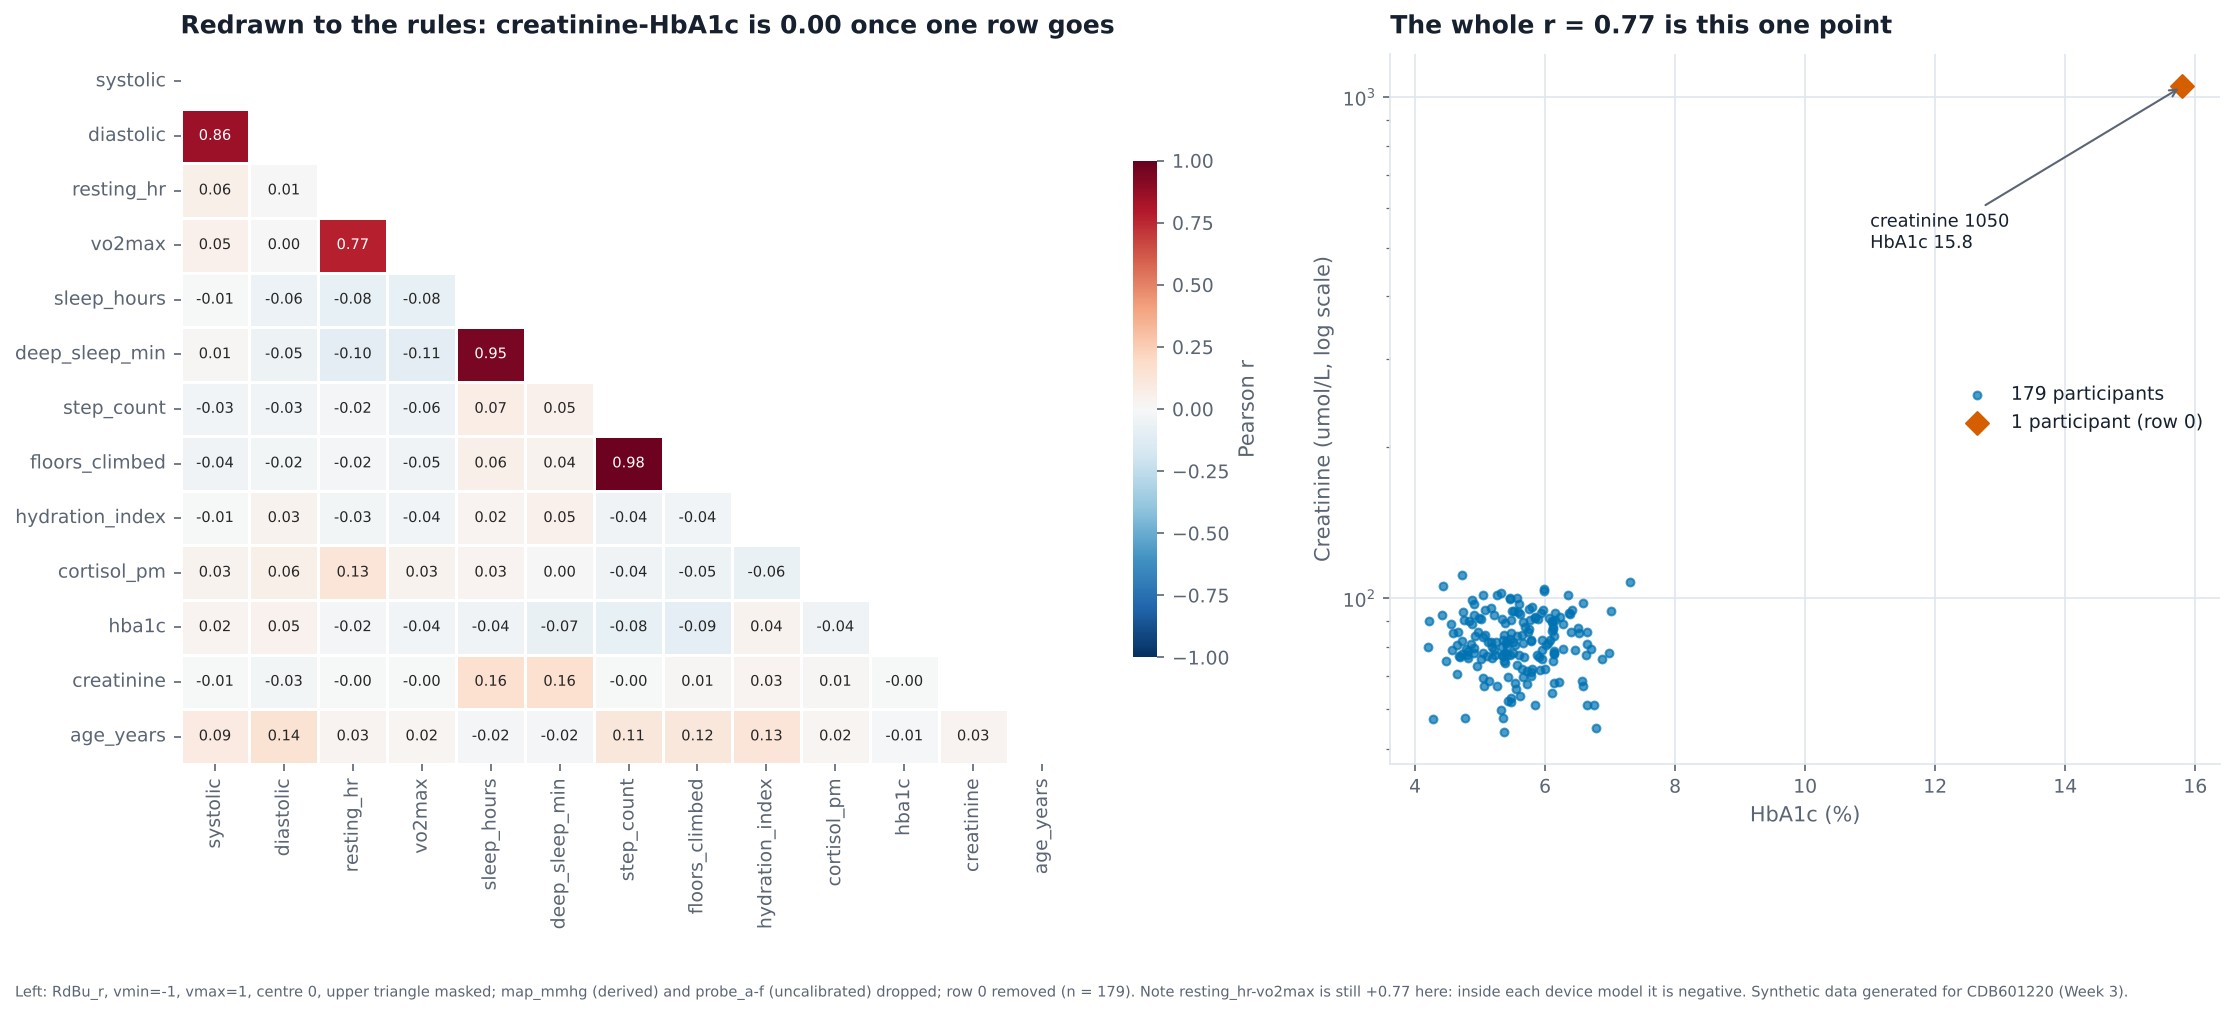

saved -> charts/partA_case06_redesign.png


'/home/claude/week3/charts/partA_case06_redesign.png'

In [23]:
keep = [c for c in num6.columns if not c.startswith("probe") and c != "map_mmhg"]
c_fixed = rest[keep].corr()
mask = np.triu(np.ones_like(c_fixed, dtype=bool))
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 6.4), gridspec_kw={"width_ratios": [1.35, 1]})
sns.heatmap(c_fixed, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.5, cbar_kws={"label": "Pearson r", "shrink": 0.7}, ax=ax)
ax.set_title("Redrawn to the rules: creatinine-HbA1c is 0.00 once one row goes")
ax.grid(False)
ax2.scatter(rest.hba1c, rest.creatinine, s=14, color=BLUE, alpha=0.7, label="179 participants")
ax2.scatter(out.hba1c, out.creatinine, s=60, color=ORANGE, marker="D", label="1 participant (row 0)")
ax2.set_yscale("log")
ax2.set_xlabel("HbA1c (%)")
ax2.set_ylabel("Creatinine (umol/L, log scale)")
ax2.legend(loc="center right")
ax2.set_title("The whole r = 0.77 is this one point")
ax2.annotate(f"creatinine {out.creatinine.iloc[0]:.0f}\nHbA1c {out.hba1c.iloc[0]}", (out.hba1c.iloc[0], out.creatinine.iloc[0]),
             xytext=(11, 500), fontsize=8.5, arrowprops=dict(arrowstyle="->", color=INK_SOFT))
fig.tight_layout()
finish(fig, "partA_case06_redesign",
       "Left: RdBu_r, vmin=-1, vmax=1, centre 0, upper triangle masked; map_mmhg (derived) and probe_a-f (uncalibrated) dropped; row 0 removed (n = 179). "
       "Note resting_hr-vo2max is still +0.77 here: inside each device model it is negative. " + SRC)

**What this chart shows.** On the left I redrew the heatmap properly with a diverging colour map. On the right you can see the 0.77 comes from one single person with extreme values. Take that one row out and the correlation is basically zero. Fixing the colours alone would not have caught this; I had to look at the actual data.

### Case 6 diagnosis

**The conclusion it invites.** The heatmap says creatinine and HbA1c are strongly linked (r = 0.77), which would suggest kidney function and blood sugar move together in this cohort.

**The decoy, and why it does not hold.** 'Correlation is not causation' is true and gets zero, so I tested a real alternative instead: maybe study site drives both. Site C does show r = 0.92, but only because it contains one participant. Without that row Site C's r is -0.11.

**The mechanism.** Two different problems. (1) What it says: the 0.77 is one participant. Row 0 has creatinine 1,050 umol/L (the other 179 are between 54 and 111) and HbA1c 15.8%. Remove that one row and r falls from 0.77 to -0.004; the Spearman correlation, which is not driven by one extreme value, is 0.03. There are other traps in the same matrix: systolic and diastolic vs map_mmhg (0.96, 0.97) are arithmetic because MAP is computed from them; resting_hr vs vo2max is +0.77, the wrong sign for physiology, and inside each heart-rate device model it is negative (-0.40 to -0.63) because the four devices read about 15 bpm apart and were used at different sites; and with 190 pairs, 20 pass p < 0.05 when about 9.5 would by pure chance, and 8 of those 'hits' involve the uncalibrated probe channels (probe_e vs diastolic r = -0.23). Only 7 pairs survive a Bonferroni correction. (2) How it is drawn: 'Reds' is a sequential map for a quantity that has a sign, and without vmin/vmax its lightest colour is the most negative r, so -0.23 and 0 look alike and nothing shows direction. Both triangles show every number twice, and the diagonal of 1s is the darkest thing on the chart.

**The redesign.** I redrew it to the Lecture 6 rules (RdBu_r, -1 to +1, centred at 0, upper triangle masked), dropped map_mmhg and the six probes, and removed the one bad row. I also plot the creatinine vs HbA1c scatter with the outlier marked. Important: fixing the drawing only fixes the sign and redundancy problems. The perfectly drawn heatmap with the outlier still shows 0.77. Only looking at the data fixes what the chart says.

---
## Case 7 - "ShaheenGo ran at a loss until May"

> Line chart with two y-axes: `revenue_pkr_m` on the left limited to 50-80, `cost_pkr_m` on the right limited to 40-56. `ax.twinx()`.

**Self-check:** the cost line sits above the revenue line for the first four months.

*This is the only dual-axis chart in my work, and it is here only because the recipe demands it.*

cost drawn above revenue: {'Jan': True, 'Feb': True, 'Mar': True, 'Apr': True, 'May': False, 'Jun': False}
self-check case 7: months with cost drawn above revenue (first four) = 4.000 (want 4)  ->  PASS
self-check case 7: ...and not after = 0.000 (want 0)  ->  PASS


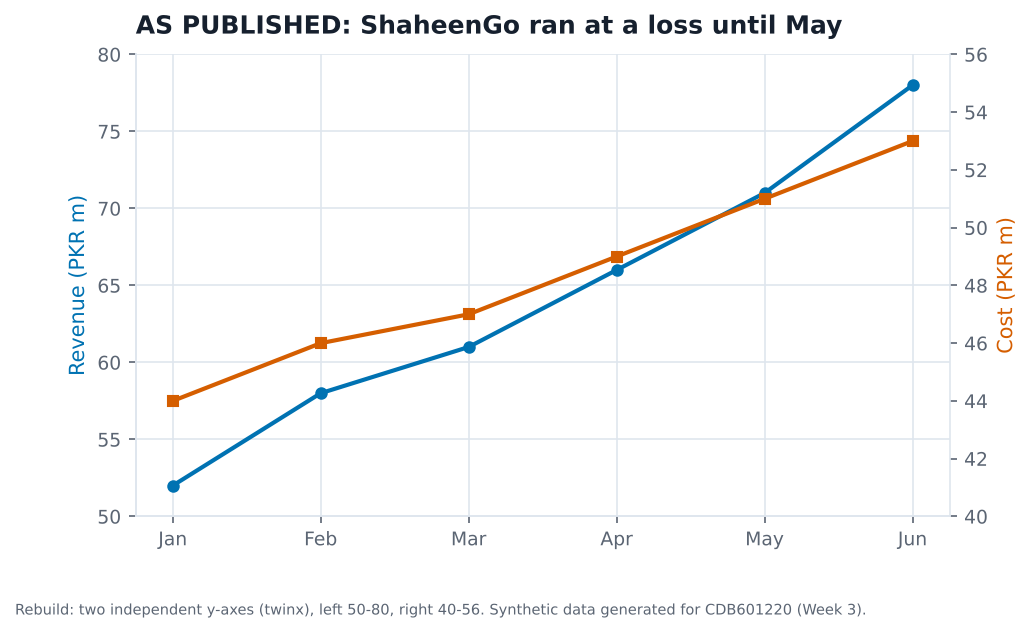

saved -> charts/partA_case07_rebuild.png


'/home/claude/week3/charts/partA_case07_rebuild.png'

In [24]:
dual = pd.read_csv(DATA / "case07_dual_axis_series.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax2 = ax.twinx()
ax.plot(dual.month, dual.revenue_pkr_m, color=BLUE, marker="o", label="Revenue")
ax2.plot(dual.month, dual.cost_pkr_m, color=ORANGE, marker="s", label="Cost")
ax.set_ylim(50, 80); ax2.set_ylim(40, 56)
ax.set_ylabel("Revenue (PKR m)", color=BLUE); ax2.set_ylabel("Cost (PKR m)", color=ORANGE)
ax2.spines["right"].set_visible(True); ax2.grid(False)
ax.set_title("AS PUBLISHED: ShaheenGo ran at a loss until May")

# self-check: where does each line sit on the canvas? (fraction of axis height)
rev_pos = (dual.revenue_pkr_m - 50) / 30
cost_pos = (dual.cost_pkr_m - 40) / 16
above = (cost_pos > rev_pos).tolist()
print("cost drawn above revenue:", dict(zip(dual.month, above)))
check(7, "months with cost drawn above revenue (first four)", sum(above[:4]), 4, 0)
check(7, "...and not after", sum(above[4:]), 0, 0)
finish(fig, "partA_case07_rebuild", "Rebuild: two independent y-axes (twinx), left 50-80, right 40-56. " + SRC)

**What this chart shows.** With two separate y-axes, the cost line sits above revenue until May, so it looks like the company was losing money. But that crossing only happens because of the limits chosen for each axis.

In [25]:
dual["profit"] = dual.revenue_pkr_m - dual.cost_pkr_m
dual["margin_%"] = 100 * dual.profit / dual.revenue_pkr_m
print(dual)
print("months where cost > revenue:", (dual.cost_pkr_m > dual.revenue_pkr_m).sum())

  month  revenue_pkr_m  cost_pkr_m  profit   margin_%
0   Jan             52          44       8  15.384615
1   Feb             58          46      12  20.689655
2   Mar             61          47      14  22.950820
3   Apr             66          49      17  25.757576
4   May             71          51      20  28.169014
5   Jun             78          53      25  32.051282
months where cost > revenue: 0


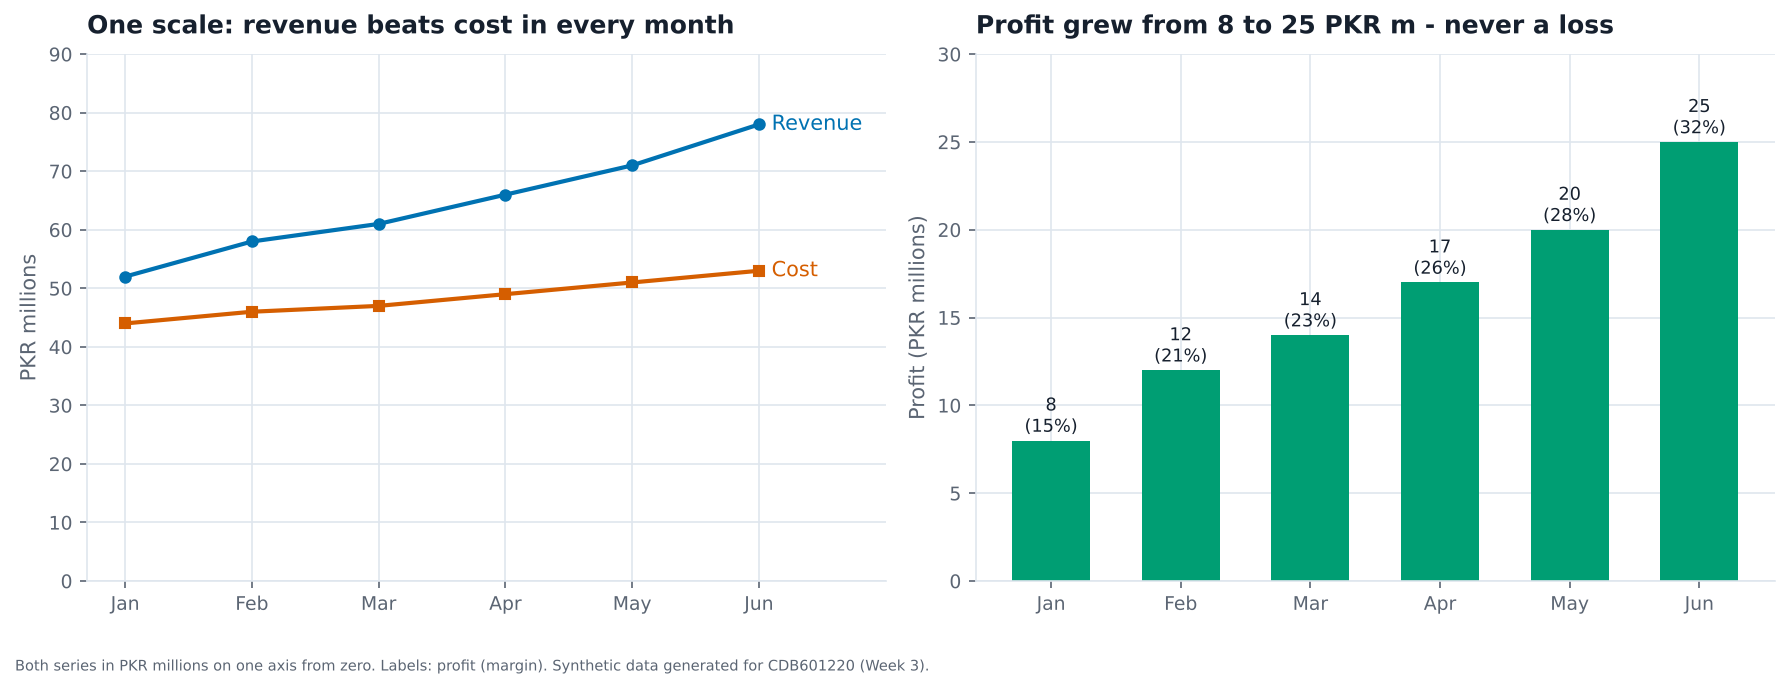

saved -> charts/partA_case07_redesign.png


'/home/claude/week3/charts/partA_case07_redesign.png'

In [26]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax.plot(dual.month, dual.revenue_pkr_m, color=BLUE, marker="o")
ax.plot(dual.month, dual.cost_pkr_m, color=ORANGE, marker="s")
ax.text(5.1, dual.revenue_pkr_m.iloc[-1], "Revenue", color=BLUE, va="center")
ax.text(5.1, dual.cost_pkr_m.iloc[-1], "Cost", color=ORANGE, va="center")
ax.set_ylim(0, 90); ax.set_xlim(-0.3, 6)
ax.set_ylabel("PKR millions")
ax.set_title("One scale: revenue beats cost in every month")
ax2.bar(dual.month, dual.profit, color=GREEN, width=0.6)
for i, (p, m) in enumerate(zip(dual.profit, dual["margin_%"])):
    ax2.text(i, p + 0.5, f"{p:.0f}\n({m:.0f}%)", ha="center", fontsize=8.5)
ax2.set_ylim(0, 30)
ax2.set_ylabel("Profit (PKR millions)")
ax2.set_title("Profit grew from 8 to 25 PKR m - never a loss")
fig.tight_layout()
finish(fig, "partA_case07_redesign", "Both series in PKR millions on one axis from zero. Labels: profit (margin). " + SRC)

**What this chart shows.** On one shared axis starting from zero, revenue is above cost every single month. Profit grows from 8 to 25 million PKR, so the company was never running at a loss.

### Case 7 diagnosis

**The conclusion it invites.** On the dual-axis chart the cost line sits above the revenue line for January to April, so the company looks loss-making until May.

**The decoy, and why it does not hold.** 'The axes are truncated' is the obvious complaint and it is partly true, but truncation alone cannot make two lines cross. If both series were on one truncated axis, revenue would still sit above cost every month. The truncation is not the mechanism.

**The mechanism.** Two independent y-axes. Revenue is mapped to 50 to 80 on the left and cost to 40 to 56 on the right, so the vertical position of each line depends only on which limits the analyst picked. Both columns are in the same unit (PKR millions), so there was never a reason for a second axis. On one shared scale revenue is above cost in every month: profit is 8, 12, 14, 17, 20 and 25 PKR m, and the margin grows from 15% to 32%. The company was profitable all along, and more so each month.

**The redesign.** Revenue and cost on one axis from zero, directly labelled, plus a second panel with monthly profit as bars. Two measures, two panels, no twinx.

---
## Case 8 - "Three bin widths, three different distributions"

> Three histograms of `systolic` side by side, sharing nothing but the data: `bins=3`, `bins=45`, `bins=400`.

**Self-check:** n = 10,000 in all three panels.

self-check case 8: n in bins=3 panel = 10000.000 (want 10000)  ->  PASS
self-check case 8: n in bins=45 panel = 10000.000 (want 10000)  ->  PASS
self-check case 8: n in bins=400 panel = 10000.000 (want 10000)  ->  PASS


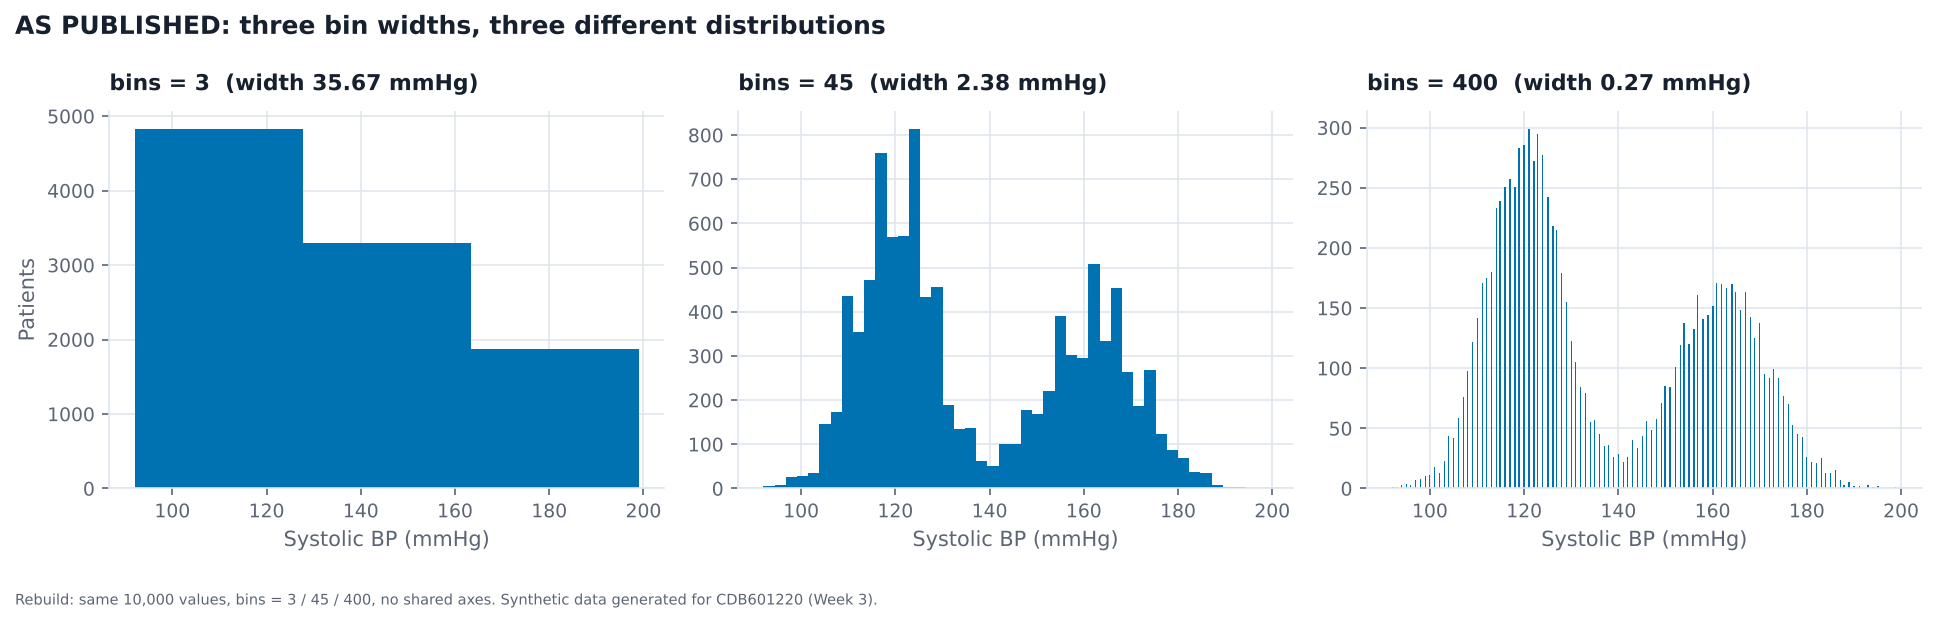

saved -> charts/partA_case08_rebuild.png


'/home/claude/week3/charts/partA_case08_rebuild.png'

In [27]:
vit = pd.read_csv(DATA / "vitals_10k.csv")
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, b in zip(axes, [3, 45, 400]):
    counts, edges, _ = ax.hist(vit.systolic, bins=b, color=BLUE)
    check(8, f"n in bins={b} panel", counts.sum(), 10000, 0)
    ax.set_title(f"bins = {b}  (width {edges[1]-edges[0]:.2f} mmHg)", fontsize=10.5)
    ax.set_xlabel("Systolic BP (mmHg)")
axes[0].set_ylabel("Patients")
fig.suptitle("AS PUBLISHED: three bin widths, three different distributions", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
finish(fig, "partA_case08_rebuild", "Rebuild: same 10,000 values, bins = 3 / 45 / 400, no shared axes. " + SRC)

**What this chart shows.** Same 10,000 numbers, three completely different-looking histograms. Only the number of bins changed. 3 bins hide the shape, and 400 bins produce a spiky comb.

In [28]:
print("last digit of systolic (decoy test for rounding to 0/5):")
print((vit.systolic % 10).value_counts().sort_index().to_dict())
print("distinct systolic values:", vit.systolic.nunique(), "(whole numbers only:", bool((vit.systolic % 1 == 0).all()), ")")
h400, e400 = np.histogram(vit.systolic, bins=400)
print(f"bins=400: width {e400[1]-e400[0]:.3f} mmHg, empty bins {np.sum(h400 == 0)} of 400")
h3, e3 = np.histogram(vit.systolic, bins=3)
print("bins=3 counts:", h3, "edges:", e3.round(1))
print(f"share above 140 mmHg: {100*(vit.systolic > 140).mean():.1f}%")

last digit of systolic (decoy test for rounding to 0/5):
{0: 994, 1: 989, 2: 955, 3: 1031, 4: 1060, 5: 1003, 6: 998, 7: 1023, 8: 962, 9: 985}
distinct systolic values: 104 (whole numbers only: True )
bins=400: width 0.267 mmHg, empty bins 296 of 400
bins=3 counts: [4829 3294 1877] edges: [ 92.  127.7 163.3 199. ]
share above 140 mmHg: 41.6%


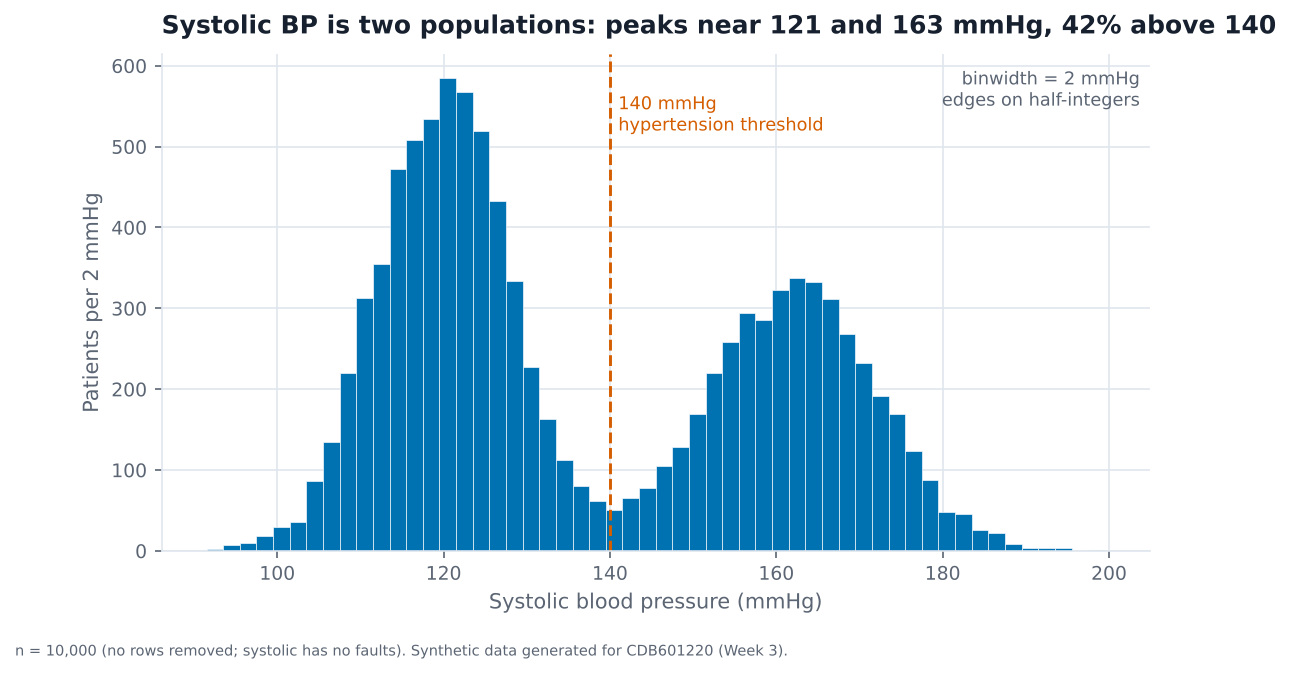

saved -> charts/partA_case08_redesign.png


'/home/claude/week3/charts/partA_case08_redesign.png'

In [29]:
edges = np.arange(vit.systolic.min() - 0.5, vit.systolic.max() + 2, 2)      # binwidth 2, half-integer edges
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(vit.systolic, bins=edges, color=BLUE, edgecolor="white", linewidth=0.3)
ax.axvline(140, color=ORANGE, ls="--", lw=1.4)
ax.text(141, ax.get_ylim()[1] * 0.92, "140 mmHg\nhypertension threshold", color=ORANGE, fontsize=8.5, va="top")
ax.text(0.99, 0.97, "binwidth = 2 mmHg\nedges on half-integers", transform=ax.transAxes, ha="right", va="top",
        fontsize=8.5, color=INK_SOFT)
ax.set_xlabel("Systolic blood pressure (mmHg)")
ax.set_ylabel("Patients per 2 mmHg")
ax.set_title(f"Systolic BP is two populations: peaks near 121 and 163 mmHg, {100*(vit.systolic>140).mean():.0f}% above 140")
finish(fig, "partA_case08_redesign", "n = 10,000 (no rows removed; systolic has no faults). " + SRC)

**What this chart shows.** With a sensible bin width of 2 mmHg, it's clear there are two groups of patients: one around 121 mmHg and a hypertensive group around 163 mmHg. 42% of patients are above 140. The 400-bin spikes only appeared because blood pressure is recorded in whole numbers.

### Case 8 diagnosis

**The conclusion it invites.** The three panels look like three different distributions: a smooth decline (3 bins), something with two humps (45 bins) and a spiky comb (400 bins). The chart suggests we cannot know the shape.

**The decoy, and why it does not hold.** I wondered if the spikes were terminal-digit preference (nurses rounding to 0 or 5). They are not: the last digits of systolic are almost perfectly uniform (between 955 and 1,060 readings for each digit 0 to 9). The data is fine; the bins are the problem.

**The mechanism.** The bin count decides what you see. With bins = 3 each bin is 35.7 mmHg wide, which merges the two populations into one falling staircase (4,829 / 3,294 / 1,877). Systolic is in fact bimodal: one group peaks around 121 mmHg and another around 163 mmHg, with 41.6% of patients above 140. With bins = 400 each bin is only 0.27 mmHg wide, but the readings are whole numbers (104 distinct values), so 296 of the 400 bins are empty. The comb is the integer grid, not noise.

**The redesign.** One histogram with binwidth = 2 mmHg, edges on half-integers so every bin holds exactly two whole values, and a reference line at 140 mmHg. The bin width is printed on the panel.

---
## Case 9 - "4.4% of the density sits above 100% saturation"

> KDE of `spo2` with the default bandwidth. Extend the x-axis to 108 so the whole curve is visible, and mark 100.

**Self-check:** the maximum value in the data is 100. The curve is not.

self-check case 9: max spo2 in data = 100.000 (want 100)  ->  PASS
curve maximum x = 101.06  (data maximum = 100)


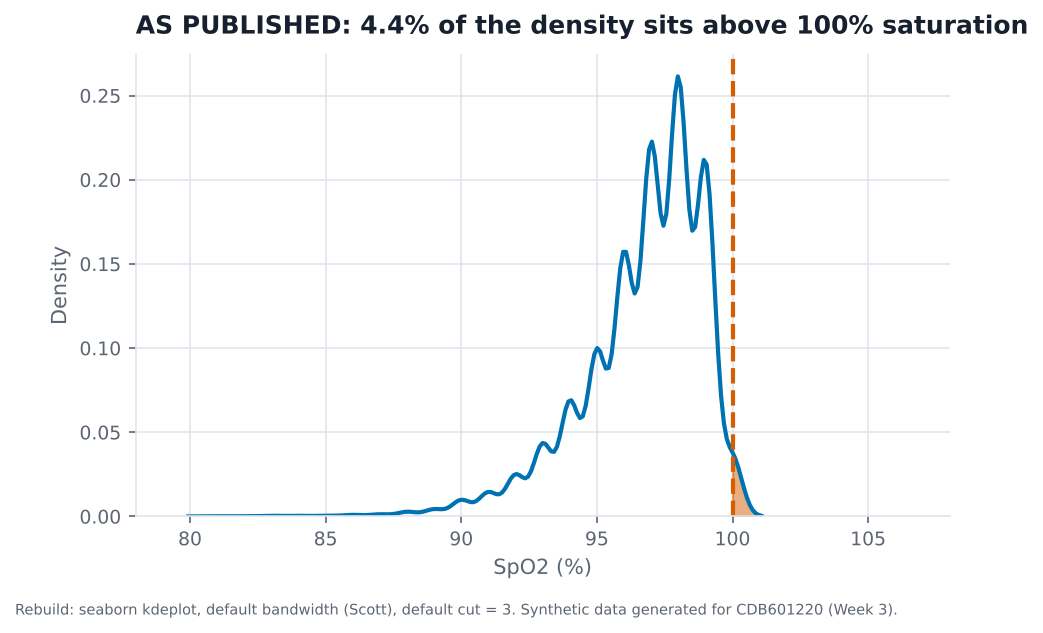

saved -> charts/partA_case09_rebuild.png


'/home/claude/week3/charts/partA_case09_rebuild.png'

In [30]:
check(9, "max spo2 in data", vit.spo2.max(), 100, 0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(vit.spo2, ax=ax, color=BLUE)
x_, y_ = ax.lines[0].get_data()
ax.fill_between(x_, y_, where=x_ > 100, color=ORANGE, alpha=0.5)
ax.axvline(100, color=ORANGE, ls="--")
ax.set_xlim(78, 108)
ax.set_xlabel("SpO2 (%)")
ax.set_title("AS PUBLISHED: 4.4% of the density sits above 100% saturation")
print(f"curve maximum x = {x_.max():.2f}  (data maximum = {vit.spo2.max()})")
finish(fig, "partA_case09_rebuild", "Rebuild: seaborn kdeplot, default bandwidth (Scott), default cut = 3. " + SRC)

**What this chart shows.** The smooth KDE curve keeps going past 100%, which makes it look like some patients have impossible oxygen levels. But the highest value in the data is exactly 100.

In [31]:
print("readings exactly at 100:", (vit.spo2 == 100).sum(), f"({100*(vit.spo2==100).mean():.1f}%)")
for bw in ["scott", "silverman"]:
    k = stats.gaussian_kde(vit.spo2, bw_method=bw)
    print(f"{bw:9s} bandwidth {k.factor*vit.spo2.std():.2f} pts | area > 100: {100*k.integrate_box_1d(100, np.inf):.2f}% "
          f"| area > 99.5: {100*k.integrate_box_1d(99.5, np.inf):.2f}%")

readings exactly at 100: 304 (3.0%)
scott     bandwidth 0.35 pts | area > 100: 1.56% | area > 99.5: 4.26%
silverman bandwidth 0.38 pts | area > 100: 1.59% | area > 99.5: 4.45%


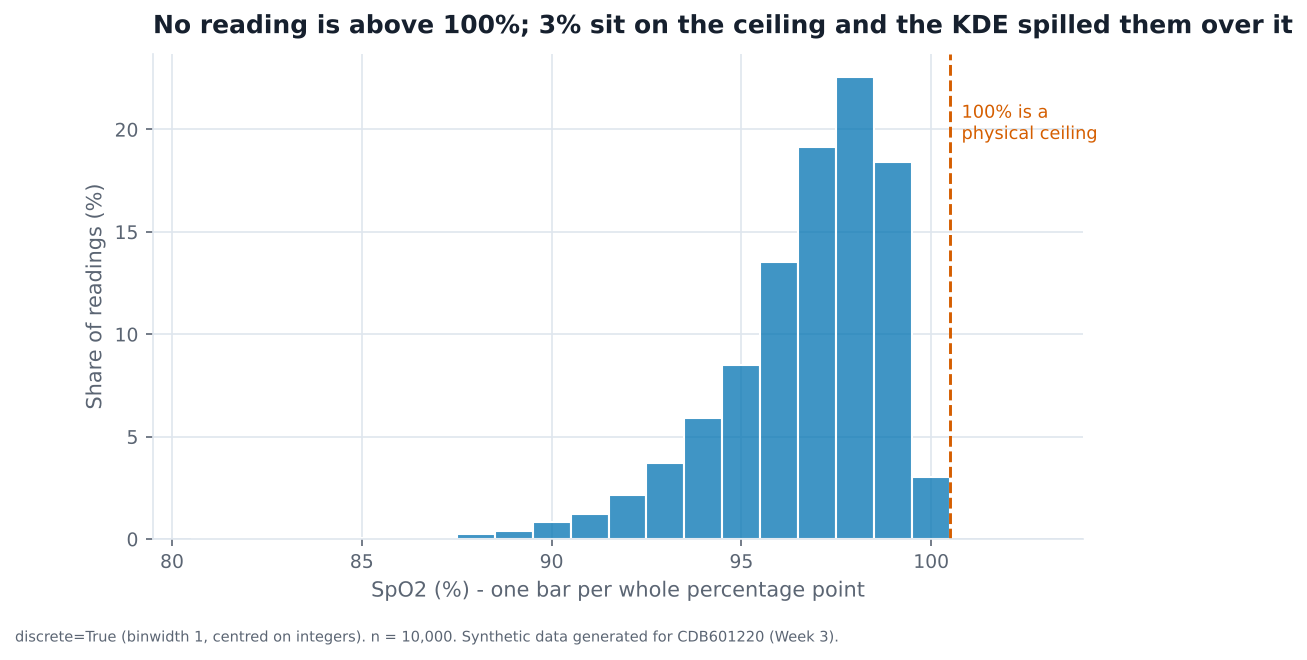

saved -> charts/partA_case09_redesign.png


'/home/claude/week3/charts/partA_case09_redesign.png'

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.histplot(vit.spo2, discrete=True, stat="percent", color=BLUE, ax=ax, edgecolor="white")
ax.axvline(100.5, color=ORANGE, ls="--", lw=1.4)
ax.text(100.8, ax.get_ylim()[1] * 0.9, "100% is a\nphysical ceiling", color=ORANGE, fontsize=8.5, va="top")
ax.set_xlim(79.5, 104)
ax.set_xlabel("SpO2 (%) - one bar per whole percentage point")
ax.set_ylabel("Share of readings (%)")
ax.set_title(f"No reading is above 100%; {100*(vit.spo2==100).mean():.0f}% sit on the ceiling and the KDE spilled them over it")
finish(fig, "partA_case09_redesign", "discrete=True (binwidth 1, centred on integers). n = 10,000. " + SRC)

**What this chart shows.** A simple bar for each whole percentage shows the real picture: nothing above 100, and 3% of readings sitting right at the ceiling. The KDE smoothing had spread those values over the limit, so the 'impossible' part of the curve was never in the data.

### Case 9 diagnosis

**The conclusion it invites.** The curve continues past 100%, so the chart suggests some patients have oxygen saturation above 100%, which is physically impossible and would mean bad data.

**The decoy, and why it does not hold.** The natural objection is data-entry errors above 100. That is ruled out: the maximum value in the file is exactly 100. No reading is impossible.

**The mechanism.** The KDE ignores the boundary. spo2 is a whole number with a hard ceiling at 100, and 304 readings (3%) sit right on it. A Gaussian kernel puts a little bell curve on every point, so the bells centred on 99 and 100 spill over the ceiling. With seaborn's default (Scott) bandwidth of 0.35 points, 1.6% of the curve's area is above 100 and 4.3% is above 99.5. The published 4.4% matches the area above 99.5 with the Silverman bandwidth (4.45%), so the analyst counted from the middle of the 100 bin. Whichever way you count it, every bit of that area is created by the smoothing, not by the data.

**The redesign.** A discrete histogram (one bar per whole percentage point, discrete=True) with the 100% ceiling marked. Nothing can appear above 100 because nothing in the data is above 100. If a smooth curve is wanted, kdeplot(cut=0, clip=(None, 100)) is the minimum fix, and it still has to be declared.

---
## All self-checks

In [33]:
sc = pd.DataFrame(SELF_CHECKS, columns=["case", "check", "my value", "target", "result"])
print(sc.to_string(index=False))
print()
print("all", len(sc), "self-checks pass" if (sc.result == "PASS").all() else "SOME SELF-CHECKS FAIL")

 case                                             check  my value    target result
    1                                Standard per 1,000     2.150     2.150   PASS
    1                                 Premium per 1,000     5.400     5.400   PASS
    2                                         Pearson r     0.982     0.980   PASS
    3                                mean AQI days 1-60   202.095   202.000   PASS
    3                              mean AQI days 61-120   137.206   137.000   PASS
    3                                            fall %    32.108    32.000   PASS
    4                           Architecture mean hours    18.000    18.000   PASS
    4                           Architecture mean score    14.501    14.500   PASS
    4                                    Architecture r     0.817     0.816   PASS
    4                Business Administration mean hours    18.000    18.000   PASS
    4                Business Administration mean score    14.501    14.500   PASS
    